In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# CSVファイルを読み込む（nrowsで読み込む行数を指定できるのでメモリに優しい）
df = pd.read_csv('run2025_none.csv')


GRtiming = df['GRQ2timing']
LASX = df['LASX']
LAStiming = df['LASQ1timing']
TOT = df['LASTOT']

In [3]:
#p,α,トラッキング、コインシデンスゲート
xdp=df['GRX']
adp=df['GRA']
ydp=df['GRY']
bdp=df['GRB']
GRQ2=df['GRQ2charge']

tracking_gated=df[
    (xdp!=-9999) & (ydp!=-9999)
]

xdp_track=tracking_gated['GRX']
adp_track=tracking_gated['GRA']
ydp_track=tracking_gated['GRY']
bdp_track=tracking_gated['GRB']
GRQ2_track=tracking_gated['GRQ2charge']

# proton_gated=tracking_gated[
#     (GRQ2_track>213.276-21.194*5) & (GRQ2_track<213.276+21.194*5)
# ]

# xdp_proton=proton_gated['GRX']
# adp_proton=proton_gated['GRA']
# ydp_proton=proton_gated['GRY']
# bdp_proton=proton_gated['GRB']
# GRQ2_proton=proton_gated['GRQ2charge']

#GRQ2とLASQ2を扱うときは、GRQ2_trackとTOTを抽出してから
# gated_208Pb = tracking_gated[
#     (GRQ2_track>213.276-21.194*5) & (GRQ2_track<213.276+21.194*5) & (TOT+0.0430496*LASX-1.3842e-5*(LASX**2)>140) & (TOT+0.0430496*LASX-1.3842e-5*(LASX**2)<170)
# ]
gated_208Pb = tracking_gated[
    (GRQ2_track>213.276-21.194*5) & (GRQ2_track<213.276+21.194*5) & (TOT+0.0430496*LASX-1.3842e-5*(LASX**2)>140) & (TOT+0.0430496*LASX-1.3842e-5*(LASX**2)<170)
]
gated_208Pb_GRQ2timing = gated_208Pb['GRQ2timing']
gated_208Pb_LASQ1timing = gated_208Pb['LASQ1timing']
gated_208Pb_GRX = gated_208Pb["GRX"]

TDiff = gated_208Pb_LASQ1timing - gated_208Pb_GRQ2timing

mean = 86.947
sigma = 3.377


#true coincidenceのみ抽出
# true_208Pb = gated_208Pb[
#     (gated_208Pb_LASQ1timing - gated_208Pb_GRQ2timing >= mean - 1 * sigma) & (gated_208Pb_LASQ1timing - gated_208Pb_GRQ2timing <= mean + 1 * sigma)
# ]
true_208Pb = gated_208Pb[
    (TDiff >= mean - 1 * sigma) & (TDiff <= mean + 1 * sigma)
]

#　コインシデンスとったやつのみ抽出
GRX_true = true_208Pb['GRX']
LASX_true = true_208Pb['LASX']
GRQ2timing_true = true_208Pb['GRQ2timing']
LASQ1timing_true = true_208Pb['LASQ1timing']


/var/folders/6q/n4qlty390djctk6jtn7xq4940000gn/T/ipykernel_1562/563797694.py:32: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  gated_208Pb = tracking_gated[


In [4]:
#Tp, Tαを再構成
# Tp = []
# for n in GRX_true:
#     Tp.append((((n * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27)

# シリーズのまま一括計算
Tp = (((GRX_true * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27

# T_alpha = []
# for n in LASX_true:
#     T_alpha.append(0.0274600000 * n + 63.8040000000)

T_alpha = 0.02746 * LASX_true + 63.804

In [5]:
print(GRX_true)
print(Tp)
print(T_alpha)

79         76.6026
402       -34.5970
1026     -400.3220
1338      287.7720
1546     -505.5870
            ...   
546303    174.0090
546736    -15.0700
547010    456.0580
547230    -72.4815
547924    183.8910
Name: GRX, Length: 1068, dtype: float64
79        315.325784
402       318.120021
1026      327.365147
1338      310.041312
1546      330.041622
             ...    
546303    312.884641
546736    317.628774
547010    305.850658
547230    319.073785
547924    312.637325
Name: GRX, Length: 1068, dtype: float64
79        68.801116
402       67.796711
1026      57.397252
1338      75.308889
1546      54.859564
            ...    
546303    67.955979
546736    67.404802
547010    79.102350
547230    67.348702
547924    72.963558
Name: LASX, Length: 1068, dtype: float64


In [6]:
# import pandas as pd

# 1. 元となるリスト
# my_list = [320.5, 320.3, 320.2, 320.8]

# 2. リストをSeriesに変換
# series_data = pd.Series(Tp)

# print(series_data)

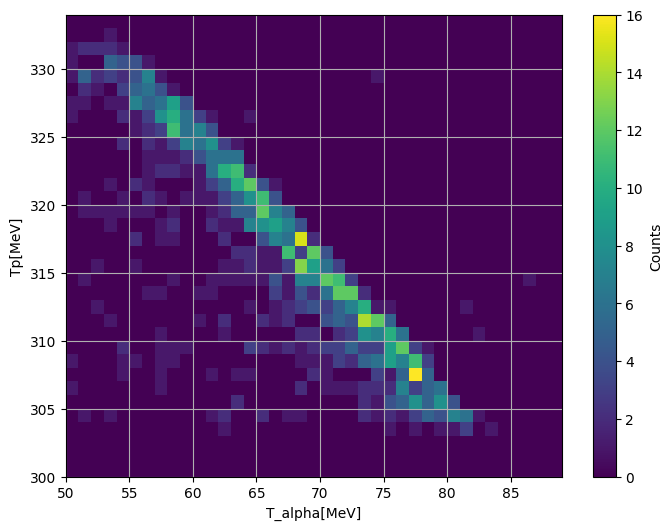

In [7]:
from matplotlib.colors import Normalize
import numpy as np
import matplotlib.pyplot as plt

#input
####################################################
#variables
x_axis_variable=T_alpha
y_axis_variable=Tp
#hist range
x_axis_range_min = 50
x_axis_range_max = 90
y_axis_range_min = 300
y_axis_range_max = 335
#bin width
x_bin_width=1
y_bin_width=1
######################################################

# ヒストグラムを作成
bins = [np.arange(x_axis_range_min, x_axis_range_max, x_bin_width),
        np.arange(y_axis_range_min, y_axis_range_max, y_bin_width)]
hist, xedges, yedges = np.histogram2d(x_axis_variable, y_axis_variable, bins=bins)

# 図の準備
fig, ax = plt.subplots(figsize=(8, 6))
# ヒートマップの作成（カウントに応じて色付け）
norm = Normalize(vmin=0, vmax=np.max(hist) // 1)  # 色の範囲を細かく調整
mesh = ax.pcolormesh(xedges, yedges, hist.T, cmap='viridis', shading='auto', norm=norm)

# カラーバーを追加
cbar = plt.colorbar(mesh, ax=ax)
cbar.set_label('Counts')

# 軸範囲とグリッド
ax.set_xlabel('T_alpha[MeV]')
ax.set_ylabel('Tp[MeV]')
ax.grid()

Text(0, 0.5, 'counts')

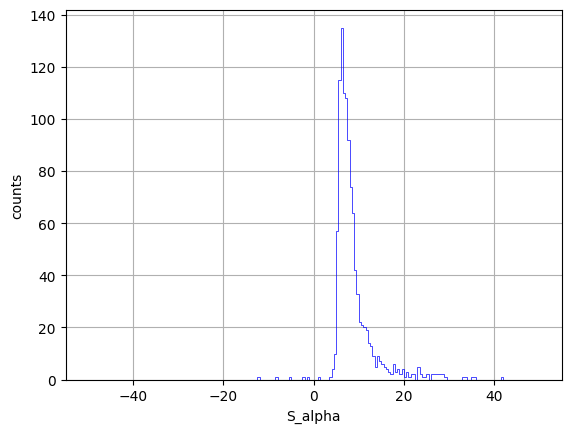

In [8]:
# リスト内包表記で各要素を足し算
# S_alpha = [392 - (a + b) for a, b in zip(Tp, T_alpha)]
S_alpha = 392 - Tp - T_alpha

variables = S_alpha

#hist range
range_min=-50
range_max=50
#bin width
x_bin_width=0.5

####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅をx_bin_widthに設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variables, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variables, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('S_alpha')
ax.set_ylabel('counts')

In [9]:
print(S_alpha)

79         7.873101
402        6.083268
1026       7.237601
1338       6.649799
1546       7.098814
            ...    
546303    11.159379
546736     6.966424
547010     7.046991
547230     5.577514
547924     6.399117
Length: 1068, dtype: float64


In [10]:
gated_325 = true_208Pb[(Tp <= 326) & (Tp >=325)]

# シリーズのまま一括計算
GRX_325 = gated_325['GRX']
LASX_325 = gated_325['LASX']

Tp_325 = (((GRX_325 * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27
T_alpha_325 = 0.02746 * LASX_325 + 63.804

Fitting parameters and their uncertainties:
Amp: 9.438 ± 0.269
Mean: 6.997 ± 0.047
Sigma: 1.443 ± 0.047


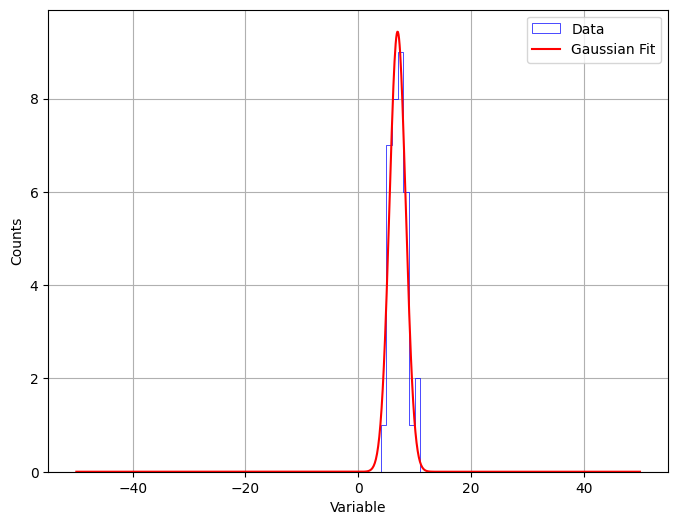

In [11]:
# Fitting
# Input
##############################################################
# Fitする変数
# variable = np.random.normal(loc=0, scale=10, size=1000)  # ダミーデータ
variable = 392 - Tp_325 - T_alpha_325
# Histogram range
hist_range_min = -50
hist_range_max = 50
# Bin width
bin_width = 1
# Fit range
fit_range_min = -20
fit_range_max = 100
# Initial parameters for the Gaussian
Amp = 250
mean = 10
sigma = 5
# Fit parameter boundaries
bound_min = [0, fit_range_min, 0]
bound_max = [np.inf, fit_range_max, np.inf]
##############################################################
# ガウシアン関数の定義
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

# データ範囲の選択
bins = np.arange(hist_range_min, hist_range_max + bin_width, bin_width)
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# フィット範囲を選択
mask = (bin_centers >= fit_range_min) & (bin_centers <= fit_range_max)
x_fit = bin_centers[mask]
y_fit = bin_counts[mask]

# 初期パラメータ
initial_guess = [Amp, mean, sigma]

# フィッティングを実行
popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=initial_guess, bounds=(bound_min, bound_max))

# フィット結果を取得
fit_y = gaussian(x_fit, *popt)

# 全てのフィッティングパラメータとその誤差を出力
print("Fitting parameters and their uncertainties:")
param_names = ["Amp", "Mean", "Sigma"]
for i, param in enumerate(popt):
    error = np.sqrt(pcov[i, i])
    print(f"{param_names[i]}: {param:.3f} ± {error:.3f}")

# フィット結果を描画
x_plot = np.linspace(hist_range_min, hist_range_max, 1000)
y_plot = gaussian(x_plot, *popt)

fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(variable, bins=bins, histtype='step', color='blue', linewidth=0.5, label='Data')
ax.plot(x_plot, y_plot, color='red', linewidth=1.5, label='Gaussian Fit')
ax.grid()
ax.set_xlabel('Variable')
ax.set_ylabel('Counts')
ax.legend()

In [12]:
gated_315 = true_208Pb[(Tp <= 316) & (Tp >=315)]

# シリーズのまま一括計算
GRX_315 = gated_315['GRX']
LASX_315 = gated_315['LASX']

Tp_315 = (((GRX_315 * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27
T_alpha_315 = 0.02746 * LASX_315 + 63.804

Fitting parameters and their uncertainties:
Amp: 11.649 ± 0.415
Mean: 7.359 ± 0.050
Sigma: 1.220 ± 0.050


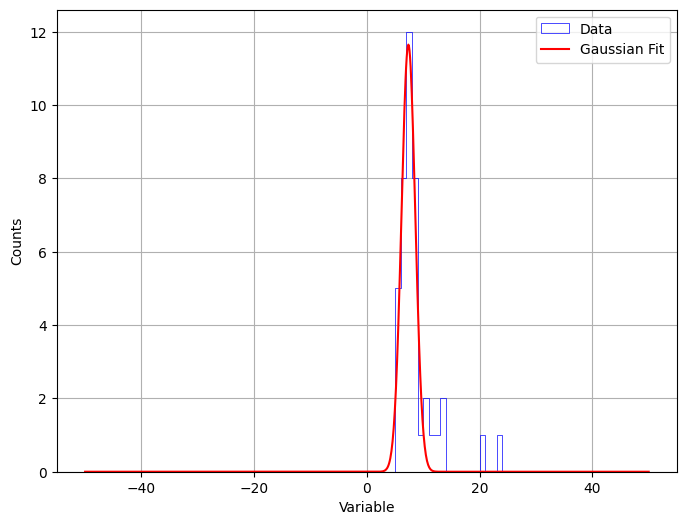

In [13]:
# Fitting
# Input
##############################################################
# Fitする変数
# variable = np.random.normal(loc=0, scale=10, size=1000)  # ダミーデータ
variable = 392 - Tp_315 - T_alpha_315
# Histogram range
hist_range_min = -50
hist_range_max = 50
# Bin width
bin_width = 1
# Fit range
fit_range_min = -20
fit_range_max = 100
# Initial parameters for the Gaussian
Amp = 250
mean = 10
sigma = 5
# Fit parameter boundaries
bound_min = [0, fit_range_min, 0]
bound_max = [np.inf, fit_range_max, np.inf]
##############################################################
# ガウシアン関数の定義
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

# データ範囲の選択
bins = np.arange(hist_range_min, hist_range_max + bin_width, bin_width)
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# フィット範囲を選択
mask = (bin_centers >= fit_range_min) & (bin_centers <= fit_range_max)
x_fit = bin_centers[mask]
y_fit = bin_counts[mask]

# 初期パラメータ
initial_guess = [Amp, mean, sigma]

# フィッティングを実行
popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=initial_guess, bounds=(bound_min, bound_max))

# フィット結果を取得
fit_y = gaussian(x_fit, *popt)

# 全てのフィッティングパラメータとその誤差を出力
print("Fitting parameters and their uncertainties:")
param_names = ["Amp", "Mean", "Sigma"]
for i, param in enumerate(popt):
    error = np.sqrt(pcov[i, i])
    print(f"{param_names[i]}: {param:.3f} ± {error:.3f}")

# フィット結果を描画
x_plot = np.linspace(hist_range_min, hist_range_max, 1000)
y_plot = gaussian(x_plot, *popt)

fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(variable, bins=bins, histtype='step', color='blue', linewidth=0.5, label='Data')
ax.plot(x_plot, y_plot, color='red', linewidth=1.5, label='Gaussian Fit')
ax.grid()
ax.set_xlabel('Variable')
ax.set_ylabel('Counts')
ax.legend()

In [14]:
gated_320 = true_208Pb[(Tp <= 321) & (Tp >= 320)]

# シリーズのまま一括計算
GRX_320 = gated_320['GRX']
LASX_320 = gated_320['LASX']

Tp_320 = (((GRX_320 * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27
T_alpha_320 = 0.02746 * LASX_320 + 63.804

Fitting parameters and their uncertainties:
Amp: 11.816 ± 0.592
Mean: 6.656 ± 0.054
Sigma: 0.918 ± 0.053


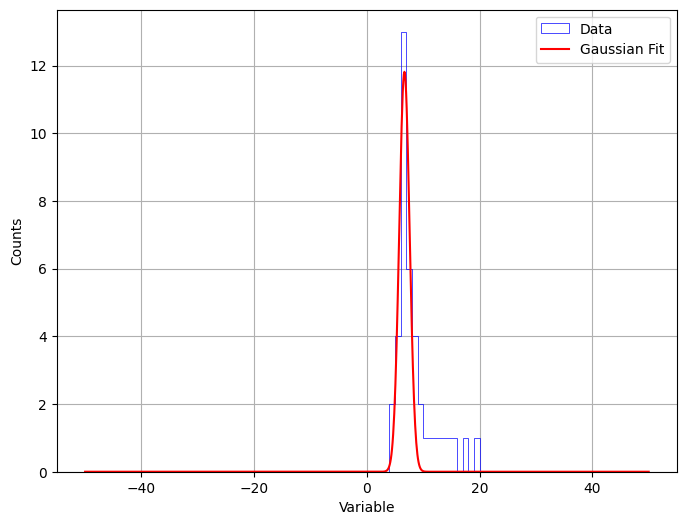

In [15]:
# Fitting
# Input
##############################################################
# Fitする変数
# variable = np.random.normal(loc=0, scale=10, size=1000)  # ダミーデータ
variable = 392 - Tp_320 - T_alpha_320
# Histogram range
hist_range_min = -50
hist_range_max = 50
# Bin width
bin_width = 1
# Fit range
fit_range_min = -20
fit_range_max = 100
# Initial parameters for the Gaussian
Amp = 250
mean = 10
sigma = 5
# Fit parameter boundaries
bound_min = [0, fit_range_min, 0]
bound_max = [np.inf, fit_range_max, np.inf]
##############################################################
# ガウシアン関数の定義
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

# データ範囲の選択
bins = np.arange(hist_range_min, hist_range_max + bin_width, bin_width)
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# フィット範囲を選択
mask = (bin_centers >= fit_range_min) & (bin_centers <= fit_range_max)
x_fit = bin_centers[mask]
y_fit = bin_counts[mask]

# 初期パラメータ
initial_guess = [Amp, mean, sigma]

# フィッティングを実行
popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=initial_guess, bounds=(bound_min, bound_max))

# フィット結果を取得
fit_y = gaussian(x_fit, *popt)

# 全てのフィッティングパラメータとその誤差を出力
print("Fitting parameters and their uncertainties:")
param_names = ["Amp", "Mean", "Sigma"]
for i, param in enumerate(popt):
    error = np.sqrt(pcov[i, i])
    print(f"{param_names[i]}: {param:.3f} ± {error:.3f}")

# フィット結果を描画
x_plot = np.linspace(hist_range_min, hist_range_max, 1000)
y_plot = gaussian(x_plot, *popt)

fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(variable, bins=bins, histtype='step', color='blue', linewidth=0.5, label='Data')
ax.plot(x_plot, y_plot, color='red', linewidth=1.5, label='Gaussian Fit')
ax.grid()
ax.set_xlabel('Variable')
ax.set_ylabel('Counts')
ax.legend()

Text(0, 0.5, 'counts')

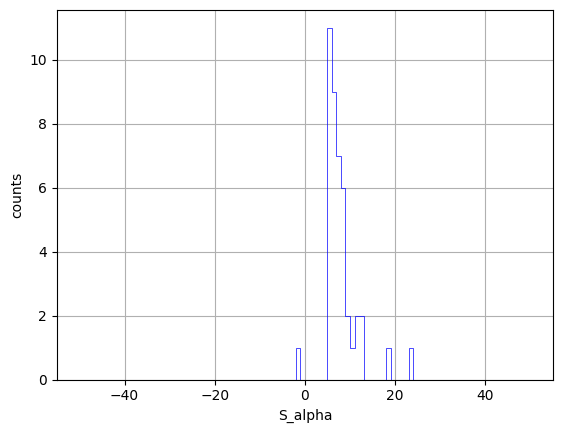

In [16]:
gated_310 = true_208Pb[(Tp <= 311) & (Tp >= 310)]

# シリーズのまま一括計算
GRX_310 = gated_310['GRX']
LASX_310 = gated_310['LASX']

Tp_310 = (((GRX_310 * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27
T_alpha_310 = 0.02746 * LASX_310 + 63.804

variables = 392 - Tp_310 - T_alpha_310

#hist range
range_min=-50
range_max=50
#bin width
x_bin_width=1

####################################################

fig=plt.figure()
ax=fig.add_subplot(111)

bin_width = x_bin_width # ビン幅をx_bin_widthに設定
bins = np.arange(range_min, range_max + bin_width, bin_width)  # ビンの境界を生成
bin_counts, bin_edges = np.histogram(variables, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # ビンの中心

ax.hist(variables, bins=bins,histtype='step', color='blue', linewidth=0.5)
ax.grid()
ax.set_xlabel('S_alpha')
ax.set_ylabel('counts')

Fitting parameters and their uncertainties:
Amp: 10.032 ± 0.608
Mean: 6.680 ± 0.102
Sigma: 1.460 ± 0.102


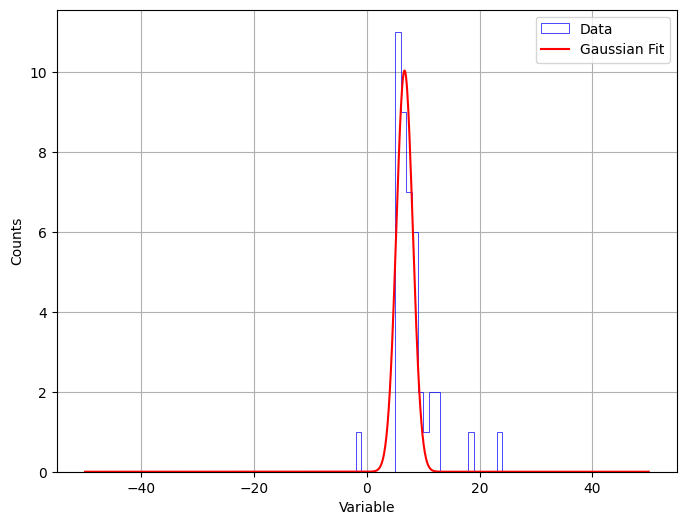

In [17]:
# Fitting
# Input
##############################################################
# Fitする変数
# variable = np.random.normal(loc=0, scale=10, size=1000)  # ダミーデータ
variable = 392 - Tp_310 - T_alpha_310
# Histogram range
hist_range_min = -50
hist_range_max = 50
# Bin width
bin_width = 1
# Fit range
fit_range_min = -20
fit_range_max = 100
# Initial parameters for the Gaussian
Amp = 250
mean = 10
sigma = 5
# Fit parameter boundaries
bound_min = [0, fit_range_min, 0]
bound_max = [np.inf, fit_range_max, np.inf]
##############################################################
# ガウシアン関数の定義
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

# データ範囲の選択
bins = np.arange(hist_range_min, hist_range_max + bin_width, bin_width)
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# フィット範囲を選択
mask = (bin_centers >= fit_range_min) & (bin_centers <= fit_range_max)
x_fit = bin_centers[mask]
y_fit = bin_counts[mask]

# 初期パラメータ
initial_guess = [Amp, mean, sigma]

# フィッティングを実行
popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=initial_guess, bounds=(bound_min, bound_max))

# フィット結果を取得
fit_y = gaussian(x_fit, *popt)

# 全てのフィッティングパラメータとその誤差を出力
print("Fitting parameters and their uncertainties:")
param_names = ["Amp", "Mean", "Sigma"]
for i, param in enumerate(popt):
    error = np.sqrt(pcov[i, i])
    print(f"{param_names[i]}: {param:.3f} ± {error:.3f}")

# フィット結果を描画
x_plot = np.linspace(hist_range_min, hist_range_max, 1000)
y_plot = gaussian(x_plot, *popt)

fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(variable, bins=bins, histtype='step', color='blue', linewidth=0.5, label='Data')
ax.plot(x_plot, y_plot, color='red', linewidth=1.5, label='Gaussian Fit')
ax.grid()
ax.set_xlabel('Variable')
ax.set_ylabel('Counts')
ax.legend()

In [18]:
#Tp vs sigmaでプロット
Tp_series = [310, 315, 320, 325]
sigma_series = [1.46, 1.22, 0.918, 1.443]
sigma_error = [0.102, 0.05, 0.053, 0.047]

Fitting result: f(x) = 8.7198e-03x^2 + -5.5506x + 884.3175


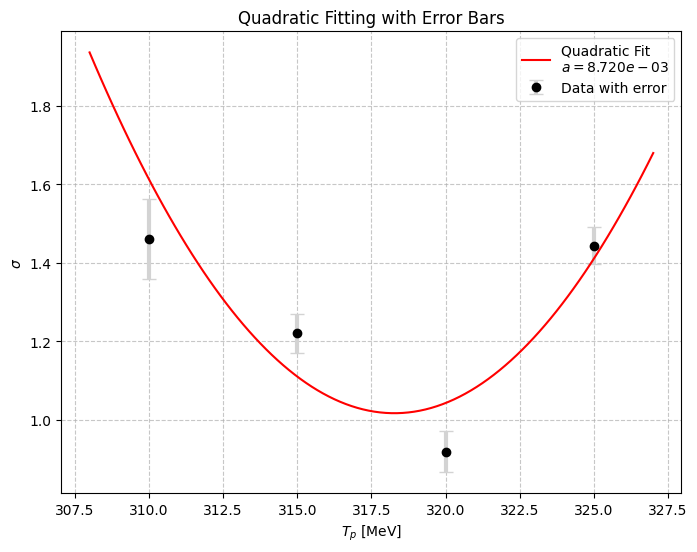

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. データの準備
x_data = np.array([310, 315, 320, 325])
y_data = np.array([1.46, 1.22, 0.918, 1.443])
y_err = np.array([0.102, 0.05, 0.053, 0.047])

# 2. 2次関数の定義
def quadratic_func(x, a, b, c):
    return a * x**2 + b * x + c

# 3. フィッティングの実行
# sigma引数に誤差を渡すことで、誤差が小さいデータ点を重視して計算します
popt, pcov = curve_fit(quadratic_func, x_data, y_data, sigma=y_err)

# 最適化されたパラメータ a, b, c の取得
a, b, c = popt
print(f"Fitting result: f(x) = {a:.4e}x^2 + {b:.4f}x + {c:.4f}")

# 4. プロット用のフィッティング曲線を作成
x_fit = np.linspace(min(x_data) - 2, max(x_data) + 2, 100)
y_fit = quadratic_func(x_fit, *popt)

# 5. 描画
plt.figure(figsize=(8, 6))

# 誤差棒付きプロット
plt.errorbar(x_data, y_data, yerr=y_err, fmt='o', color='black', 
             ecolor='lightgray', elinewidth=3, capsize=5, label='Data with error')

# フィッティング曲線のプロット
plt.plot(x_fit, y_fit, color='red', label=f'Quadratic Fit\n$a={a:.3e}$')

# グラフの装飾
plt.title('Quadratic Fitting with Error Bars')
plt.xlabel('$T_p$ [MeV]')
plt.ylabel('$\sigma$')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# 保存または表示
plt.savefig('quadratic_fit_plot.png')
plt.show()

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 結果を格納するリスト
tp_centers = []
sigma_values = []
sigma_errors = []

# 310から325まで1刻みでループ（範囲は必要に応じて調整してください）
for t_start in range(310, 326):
    t_end = t_start + 2
    
    # 1. データの抽出（ゲート設定）
    mask = (Tp >= t_start) & (Tp < t_end)
    gated_data = true_208Pb[mask]
    
    # データが少なすぎる場合はスキップ
    if len(gated_data) < 10:
        print(f"Skipping range {t_start}-{t_end}: Not enough data.")
        continue

    # 2. 計算処理
    grx = gated_data['GRX']
    lasx = gated_data['LASX']
    
    # $T_p$ と $T_{\alpha}$ の計算
    tp_calc = (((grx * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27
    t_alpha_calc = 0.02746 * lasx + 63.804
    
    # フィット対象の変数 (Excitation Energyなど)
    variable = 392 - tp_calc - t_alpha_calc
    
    # 3. ヒストグラム作成
    bins = np.arange(hist_range_min, hist_range_max + bin_width, bin_width)
    bin_counts, bin_edges = np.histogram(variable, bins=bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

    # 4. フィッティング
    mask_fit = (bin_centers >= fit_range_min) & (bin_centers <= fit_range_max)
    x_fit = bin_centers[mask_fit]
    y_fit = bin_counts[mask_fit]

    try:
        # 初期値の設定（前回のパラメータを流用するか固定値）
        popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=[Amp, mean, sigma], bounds=(bound_min, bound_max))
        
        # 5. パラメータの抽出
        current_sigma = popt[2]
        current_sigma_err = np.sqrt(pcov[2, 2])
        
        # リストに追加
        tp_centers.append(t_start + 1) # 範囲の中央値をx軸用にする
        sigma_values.append(current_sigma)
        sigma_errors.append(current_sigma_err)
        
        print(f"Range {t_start}-{t_end}: Sigma = {current_sigma:.3f} ± {current_sigma_err:.3f}")
        
    except RuntimeError:
        print(f"Range {t_start}-{t_end}: Fit failed.")

# 最後に抽出したリストを確認
print("\nFinal Result Lists:")
print(f"Tp_centers: {tp_centers}")
print(f"Sigma_values: {sigma_values}")
print(f"Sigma_errors: {sigma_errors}")

Range 310-312: Sigma = 1.344 ± 0.073
Range 311-313: Sigma = 1.421 ± 0.086
Range 312-314: Sigma = 0.847 ± 0.056
Range 313-315: Sigma = 1.040 ± 0.054
Range 314-316: Sigma = 1.273 ± 0.056
Range 315-317: Sigma = 1.456 ± 0.054
Range 316-318: Sigma = 1.484 ± 0.073
Range 317-319: Sigma = 1.481 ± 0.075
Range 318-320: Sigma = 1.546 ± 0.066
Range 319-321: Sigma = 1.326 ± 0.058
Range 320-322: Sigma = 1.029 ± 0.044
Range 321-323: Sigma = 1.313 ± 0.067
Range 322-324: Sigma = 1.493 ± 0.145
Range 323-325: Sigma = 1.457 ± 0.073
Range 324-326: Sigma = 1.418 ± 0.033
Range 325-327: Sigma = 1.431 ± 0.054

Final Result Lists:
Tp_centers: [311, 312, 313, 314, 315, 316, 317, 318, 319, 320, 321, 322, 323, 324, 325, 326]
Sigma_values: [np.float64(1.3435424804342782), np.float64(1.4205879311677516), np.float64(0.8469924200285548), np.float64(1.0396483939506522), np.float64(1.2730764606132088), np.float64(1.455556170762228), np.float64(1.4838325406298343), np.float64(1.4810107735276508), np.float64(1.54620179581

In [21]:
print(len(sigma_values))

16


Fitting result: f(x) = 3.4635e-05x^2 + -0.0053x + -0.5373


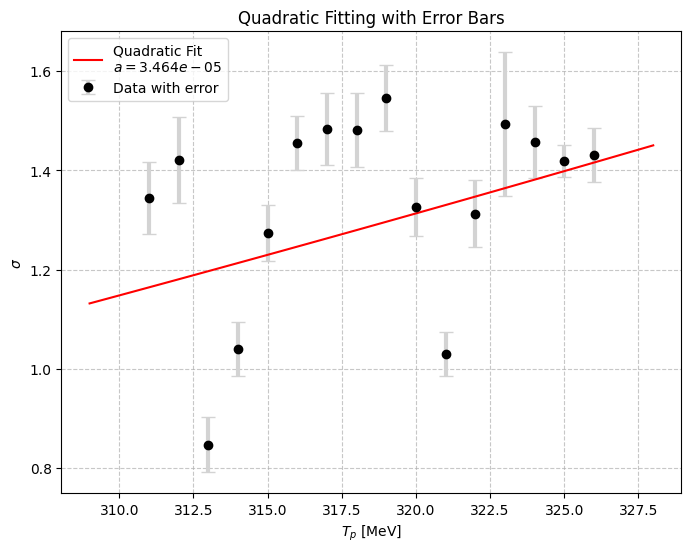

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# 1. データの準備
x_data = tp_centers
y_data = sigma_values
y_err = sigma_errors

# 2. 2次関数の定義
def quadratic_func(x, a, b, c):
    return a * x**2 + b * x + c

# 3. フィッティングの実行
# sigma引数に誤差を渡すことで、誤差が小さいデータ点を重視して計算します
popt, pcov = curve_fit(quadratic_func, x_data, y_data, sigma=y_err)

# 最適化されたパラメータ a, b, c の取得
a, b, c = popt
print(f"Fitting result: f(x) = {a:.4e}x^2 + {b:.4f}x + {c:.4f}")

# 4. プロット用のフィッティング曲線を作成
x_fit = np.linspace(min(x_data) - 2, max(x_data) + 2, 100)
y_fit = quadratic_func(x_fit, *popt)

# 5. 描画
plt.figure(figsize=(8, 6))

# 誤差棒付きプロット
plt.errorbar(x_data, y_data, yerr=y_err, fmt='o', color='black', 
             ecolor='lightgray', elinewidth=3, capsize=5, label='Data with error')

# フィッティング曲線のプロット
plt.plot(x_fit, y_fit, color='red', label=f'Quadratic Fit\n$a={a:.3e}$')

# グラフの装飾
plt.title('Quadratic Fitting with Error Bars')
plt.xlabel('$T_p$ [MeV]')
plt.ylabel('$\sigma$')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# 保存または表示
# plt.savefig('quadratic_fit_plot.png')
plt.show()

Fitting parameters and their uncertainties:
Amp: 44.884 ± 1.072
Mean: 6.751 ± 0.045
Sigma: 1.255 ± 0.033


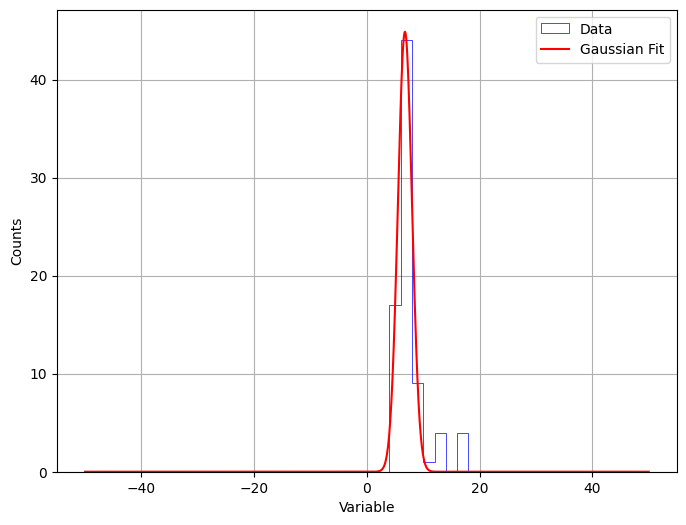

In [28]:
gated_320 = true_208Pb[(Tp <= 322) & (Tp >= 320)]

# シリーズのまま一括計算
GRX_320 = gated_320['GRX']
LASX_320 = gated_320['LASX']
LASA_320 = gated_320['LASA']

# LASX_320m = LASA_320 * (-100) +  LASX_320
LASX_320m = LASX_320 + 900 * LASA_320

Tp_320 = (((GRX_320 * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27
T_alpha_320 = 0.02746 * LASX_320m + 63.804

# Fitting
# Input
##############################################################
# Fitする変数
# variable = np.random.normal(loc=0, scale=10, size=1000)  # ダミーデータ
variable = 392 - Tp_320 - T_alpha_320
# Histogram range
hist_range_min = -50
hist_range_max = 50
# Bin width
bin_width = 2
# Fit range
fit_range_min = -20
fit_range_max = 100
# Initial parameters for the Gaussian
Amp = 250
mean = 10
sigma = 5
# Fit parameter boundaries
bound_min = [0, fit_range_min, 0]
bound_max = [np.inf, fit_range_max, np.inf]
##############################################################
# ガウシアン関数の定義
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

# データ範囲の選択
bins = np.arange(hist_range_min, hist_range_max + bin_width, bin_width)
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# フィット範囲を選択
mask = (bin_centers >= fit_range_min) & (bin_centers <= fit_range_max)
x_fit = bin_centers[mask]
y_fit = bin_counts[mask]

# 初期パラメータ
initial_guess = [Amp, mean, sigma]

# フィッティングを実行
popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=initial_guess, bounds=(bound_min, bound_max))

# フィット結果を取得
fit_y = gaussian(x_fit, *popt)

# 全てのフィッティングパラメータとその誤差を出力
print("Fitting parameters and their uncertainties:")
param_names = ["Amp", "Mean", "Sigma"]
for i, param in enumerate(popt):
    error = np.sqrt(pcov[i, i])
    print(f"{param_names[i]}: {param:.3f} ± {error:.3f}")

# フィット結果を描画
x_plot = np.linspace(hist_range_min, hist_range_max, 1000)
y_plot = gaussian(x_plot, *popt)

fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(variable, bins=bins, histtype='step', color='blue', linewidth=0.5, label='Data')
ax.plot(x_plot, y_plot, color='red', linewidth=1.5, label='Gaussian Fit')
ax.grid()
ax.set_xlabel('Variable')
ax.set_ylabel('Counts')
ax.legend()

Fitting result: f(x) = 3.0495e-06x^2 + -0.0029x + 1.4012


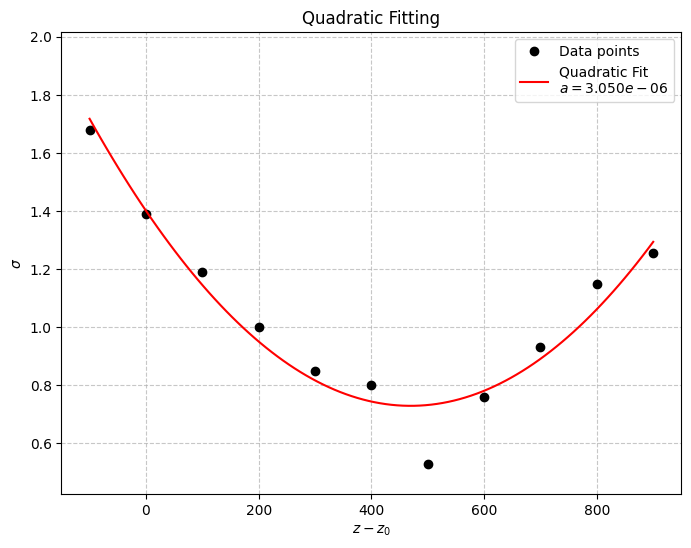

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# 1. データの準備
# x_data = np.array([-400, -300, -200, -100, 0, 100, 200, 300, 400, 500, 600, 700, 800, 900])
# y_data = np.array([1.89, 1.78, 1.72, 1.68, 1.39, 1.19, 1, 0.85, 0.8, 0.53, 0.76, 0.93, 1.15, 1.255])

x_data = np.array([-100, 0, 100, 200, 300, 400, 500, 600, 700, 800, 900])
y_data = np.array([1.68, 1.39, 1.19, 1, 0.85, 0.8, 0.53, 0.76, 0.93, 1.15, 1.255])

# 2. フィッティングの実行 (np.polyfit を使用)
# 2次式なので 2 を指定。戻り値は [a, b, c] (ax^2 + bx + c)
coeffs = np.polyfit(x_data, y_data, 2)
a, b, c = coeffs

print(f"Fitting result: f(x) = {a:.4e}x^2 + {b:.4f}x + {c:.4f}")

# 3. プロット用のフィッティング曲線を作成
x_fit = np.linspace(min(x_data), max(x_data), 100)
# np.polyval を使うと係数から y の値を簡単に計算できます
y_fit = np.polyval(coeffs, x_fit)

# 4. 描画
plt.figure(figsize=(8, 6))

# データ点のプロット (誤差がないので scatter または plot)
plt.plot(x_data, y_data, 'ko', label='Data points')

# フィッティング曲線のプロット
plt.plot(x_fit, y_fit, color='red', label=f'Quadratic Fit\n$a={a:.3e}$')

# グラフの装飾
plt.title('Quadratic Fitting')
plt.xlabel('$z-z_0$')
plt.ylabel('$\sigma$')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# 軸の範囲を自動調整（異常値によるスケール崩れを防ぐ）
plt.ylim(min(y_data)*0.8, max(y_data)*1.2)

plt.savefig('fixed_quadratic_fit.png')
plt.show()

軸の位置 (x): 469.53
頂点の座標: (469.53, 0.73)


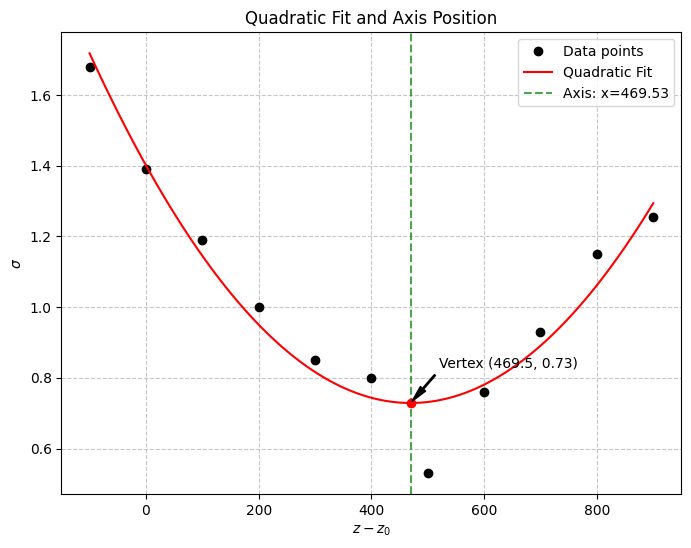

In [75]:
import numpy as np
import matplotlib.pyplot as plt

# 1. データの準備
x_data = np.array([-100, 0, 100, 200, 300, 400, 500, 600, 700, 800, 900])
y_data = np.array([1.68, 1.39, 1.19, 1, 0.85, 0.8, 0.53, 0.76, 0.93, 1.15, 1.255])

# 2. フィッティングの実行
coeffs = np.polyfit(x_data, y_data, 2)
a, b, c = coeffs

# 3. 軸の計算 (x = -b / 2a)
axis_x = -b / (2 * a)
axis_y = np.polyval(coeffs, axis_x) # 頂点のy座標

print(f"軸の位置 (x): {axis_x:.2f}")
print(f"頂点の座標: ({axis_x:.2f}, {axis_y:.2f})")

# 4. プロット用のデータ作成
x_fit = np.linspace(min(x_data), max(x_data), 100)
y_fit = np.polyval(coeffs, x_fit)

# 5. 描画
plt.figure(figsize=(8, 6))
plt.plot(x_data, y_data, 'ko', label='Data points')
plt.plot(x_fit, y_fit, color='red', label='Quadratic Fit')

# 軸（垂直線）を表示
plt.axvline(x=axis_x, color='green', linestyle='--', alpha=0.7, label=f'Axis: x={axis_x:.2f}')

# 頂点にマークを付ける
plt.plot(axis_x, axis_y, 'ro')
plt.annotate(f'Vertex ({axis_x:.1f}, {axis_y:.2f})', 
             xy=(axis_x, axis_y), xytext=(axis_x+50, axis_y+0.1),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

# グラフの装飾
plt.title('Quadratic Fit and Axis Position')
plt.xlabel('$z-z_0$')
plt.ylabel('$\sigma$')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# plt.savefig('quadratic_fit_with_axis.png')
plt.show()

Fitting parameters and their uncertainties:
Amp: 40.066 ± 1.018
Mean: 6.669 ± 0.045
Sigma: 1.369 ± 0.039


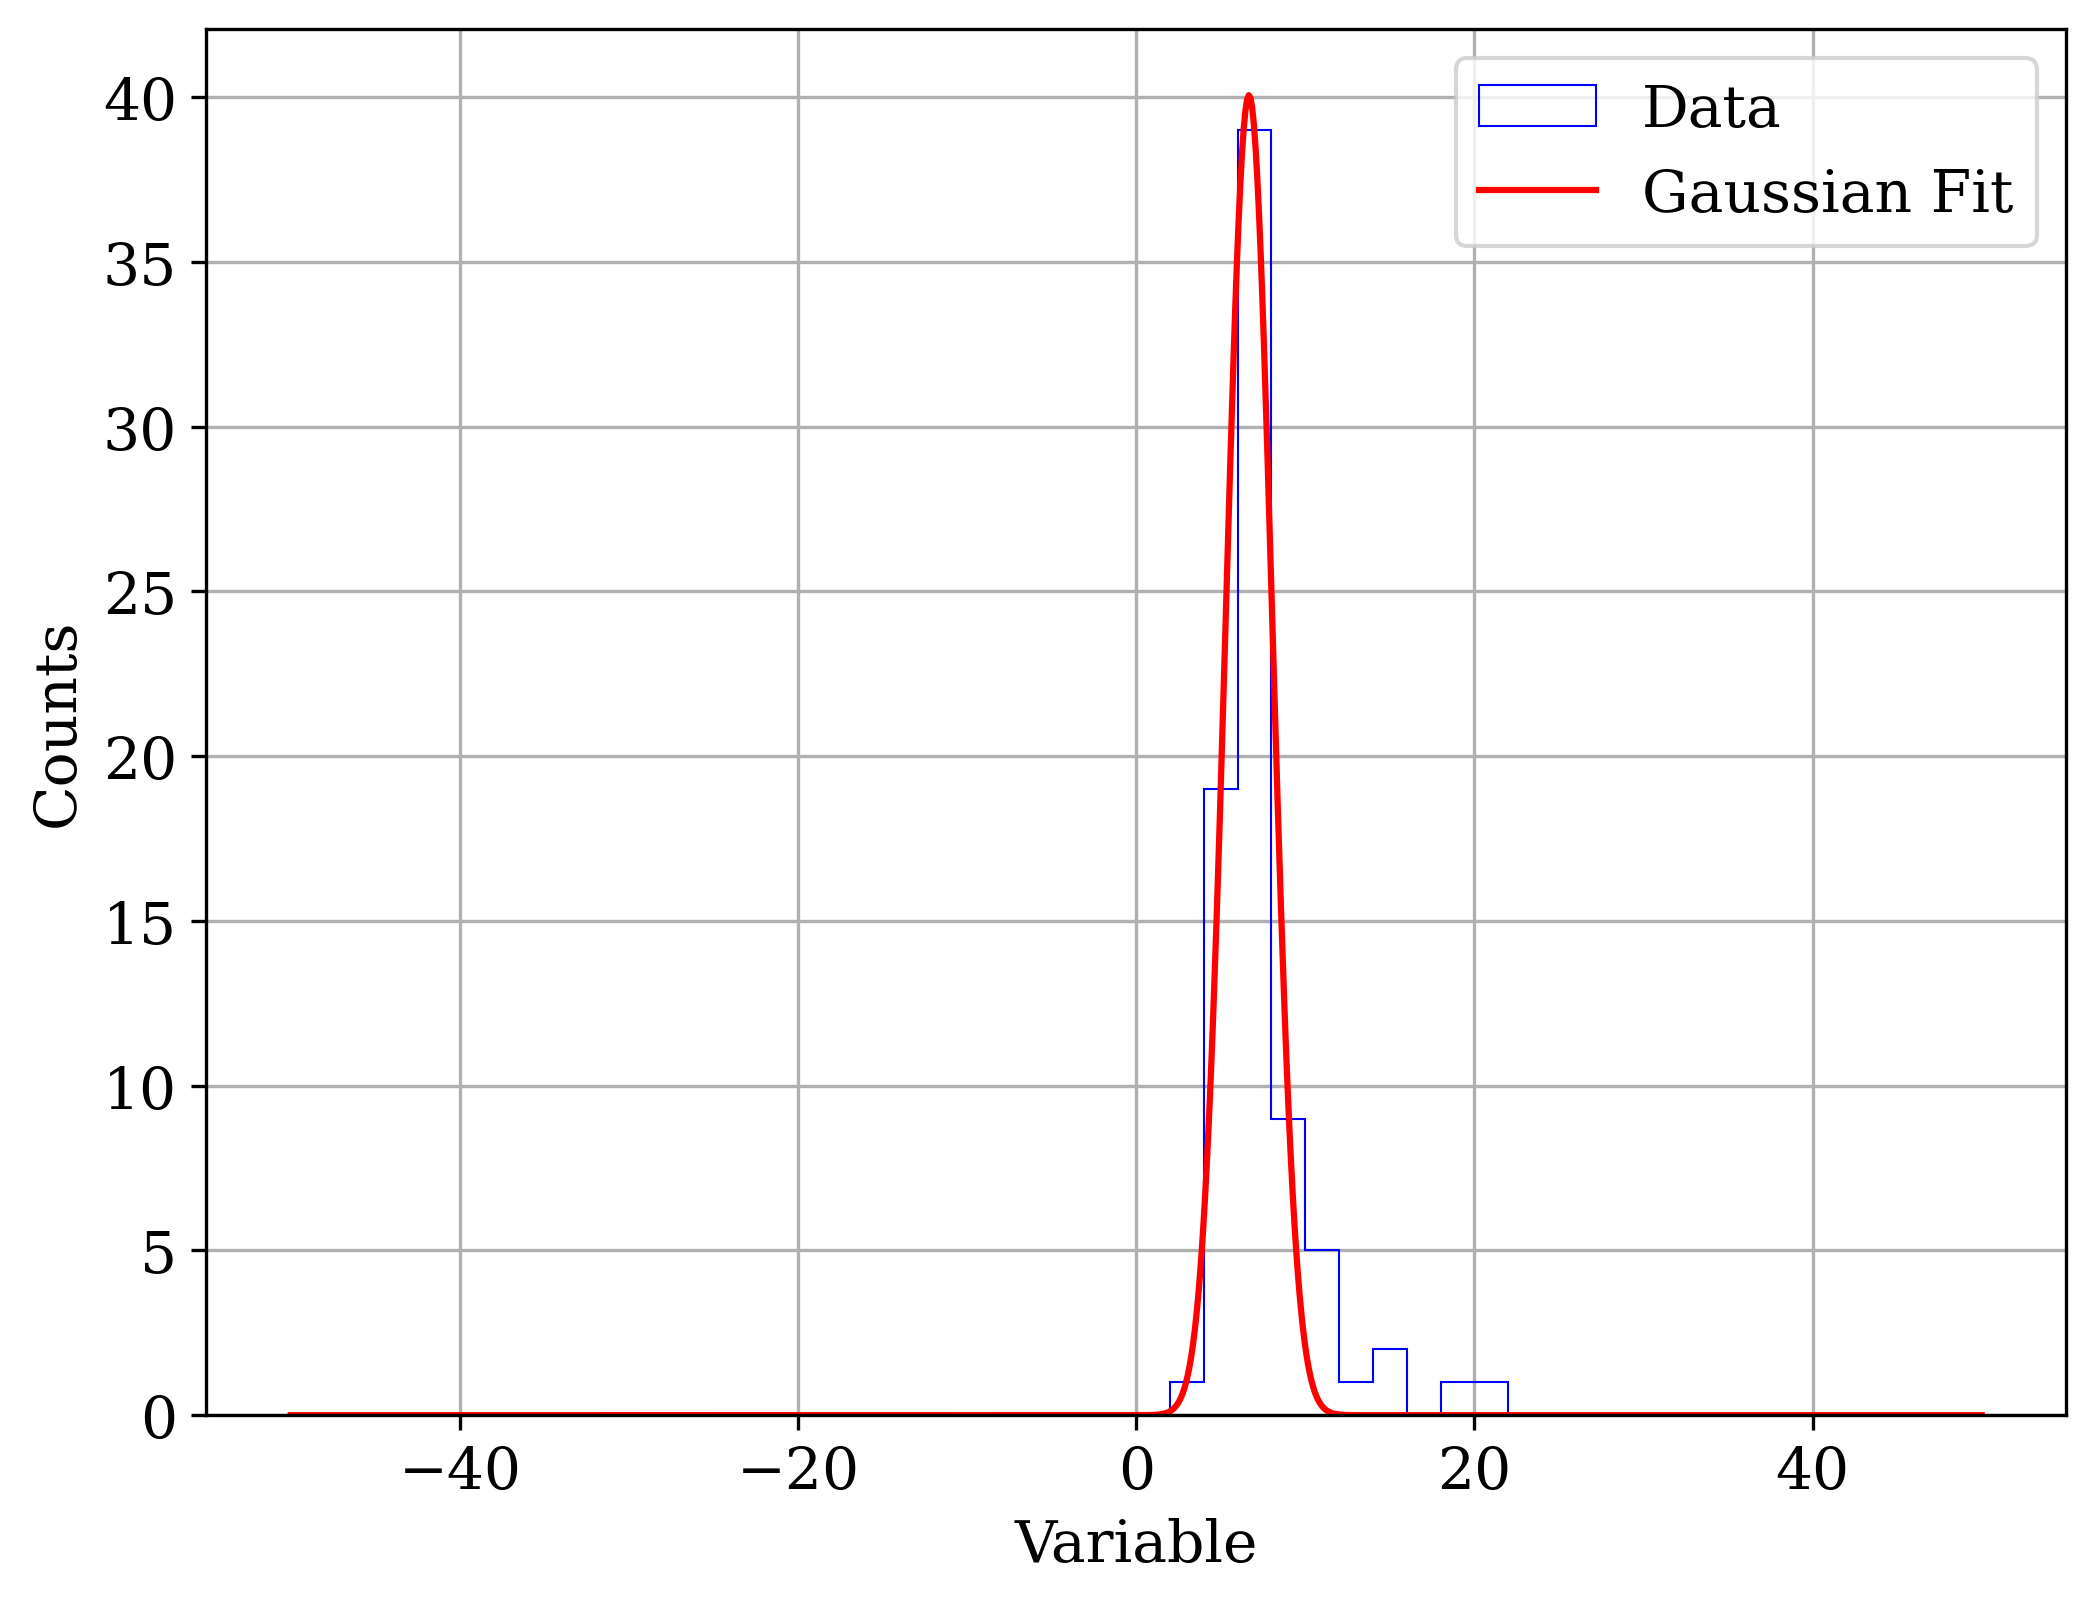

In [98]:
gated_315 = true_208Pb[(Tp <= 317) & (Tp >= 315)]

# シリーズのまま一括計算
GRX_315 = gated_315['GRX']
LASX_315 = gated_315['LASX']
LASA_315 = gated_315['LASA']

# LASX_320m = LASA_320 * (-100) +  LASX_320
LASX_315m = LASX_315 + 650 * LASA_315

Tp_315 = (((GRX_315 * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27
T_alpha_315 = 0.02746 * LASX_315m + 63.804

# Fitting
# Input
##############################################################
# Fitする変数
# variable = np.random.normal(loc=0, scale=10, size=1000)  # ダミーデータ
variable = 392 - Tp_315 - T_alpha_315
# Histogram range
hist_range_min = -50
hist_range_max = 50
# Bin width
bin_width = 2
# Fit range
fit_range_min = -20
fit_range_max = 100
# Initial parameters for the Gaussian
Amp = 250
mean = 10
sigma = 5
# Fit parameter boundaries
bound_min = [0, fit_range_min, 0]
bound_max = [np.inf, fit_range_max, np.inf]
##############################################################
# ガウシアン関数の定義
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

# データ範囲の選択
bins = np.arange(hist_range_min, hist_range_max + bin_width, bin_width)
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# フィット範囲を選択
mask = (bin_centers >= fit_range_min) & (bin_centers <= fit_range_max)
x_fit = bin_centers[mask]
y_fit = bin_counts[mask]

# 初期パラメータ
initial_guess = [Amp, mean, sigma]

# フィッティングを実行
popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=initial_guess, bounds=(bound_min, bound_max))

# フィット結果を取得
fit_y = gaussian(x_fit, *popt)

# 全てのフィッティングパラメータとその誤差を出力
print("Fitting parameters and their uncertainties:")
param_names = ["Amp", "Mean", "Sigma"]
for i, param in enumerate(popt):
    error = np.sqrt(pcov[i, i])
    print(f"{param_names[i]}: {param:.3f} ± {error:.3f}")

# フィット結果を描画
x_plot = np.linspace(hist_range_min, hist_range_max, 1000)
y_plot = gaussian(x_plot, *popt)

fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(variable, bins=bins, histtype='step', color='blue', linewidth=0.5, label='Data')
ax.plot(x_plot, y_plot, color='red', linewidth=1.5, label='Gaussian Fit')
ax.grid()
ax.set_xlabel('Variable')
ax.set_ylabel('Counts')
ax.legend()

Fitting result: f(x) = 2.7136e-06x^2 + -0.0024x + 1.5425


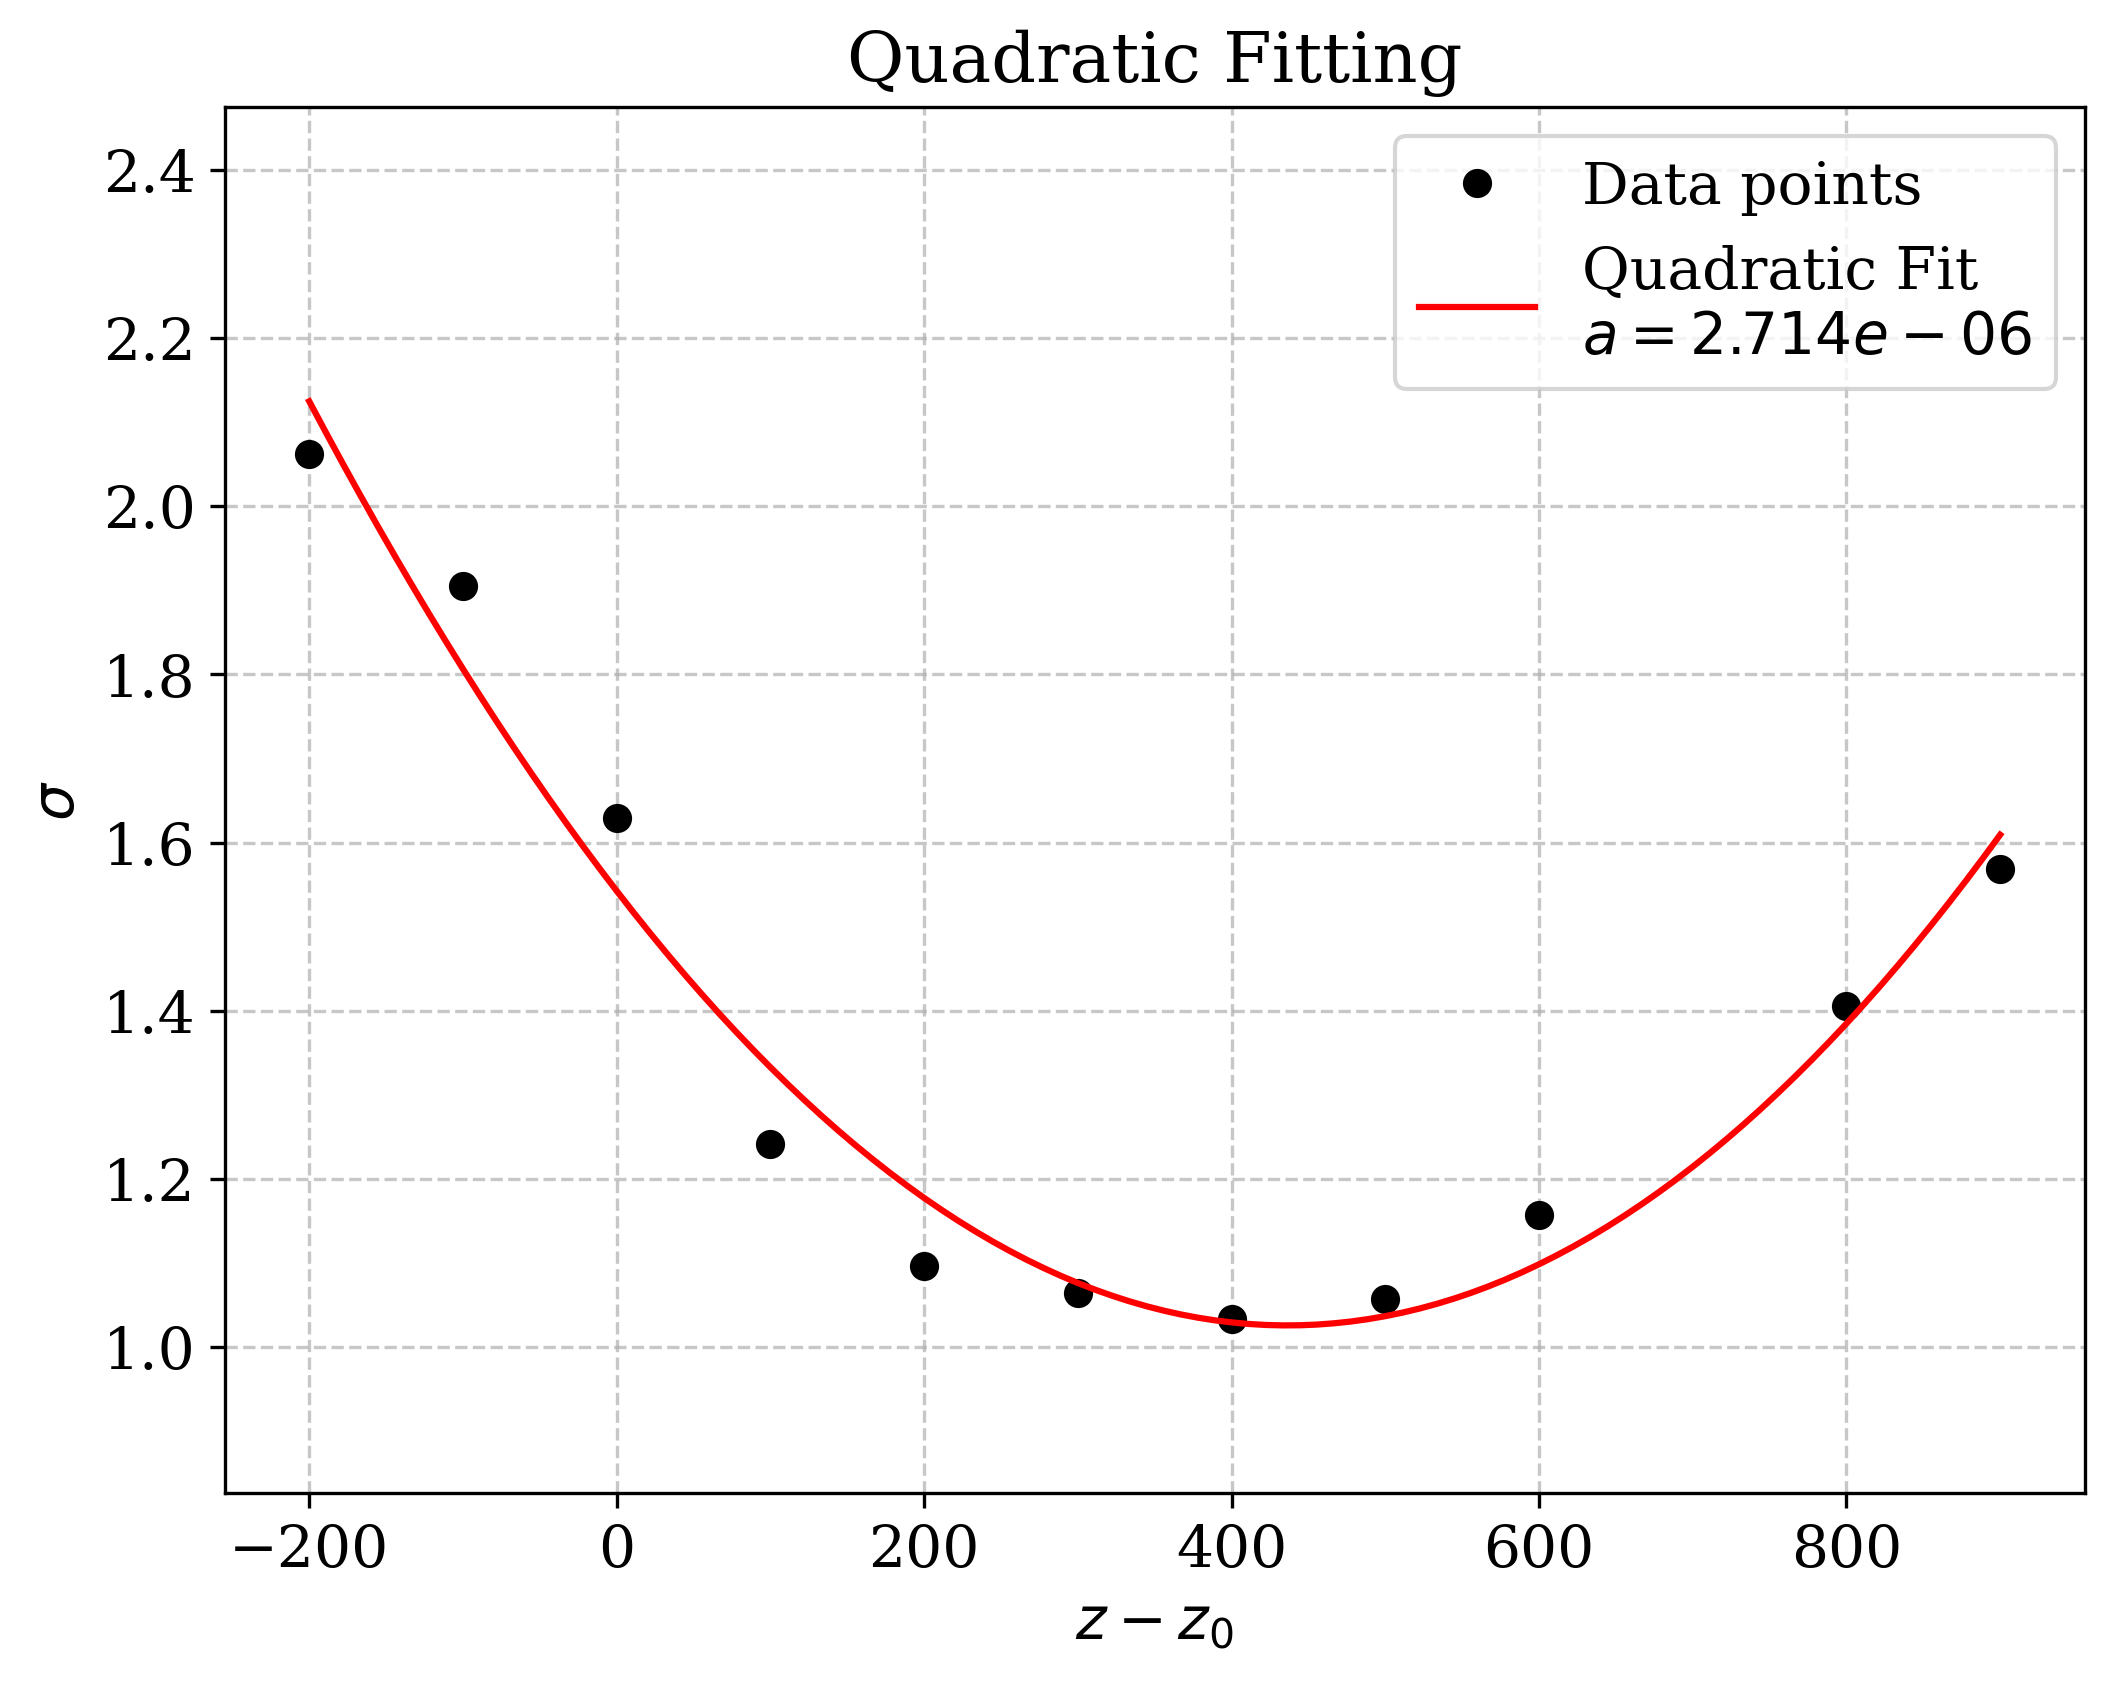

In [100]:
import numpy as np
import matplotlib.pyplot as plt

# 1. データの準備

# x_data = np.array([-200, -100, 0, 100, 200, 300, 400, 500, 600, 700, 800, 900])
# y_data = np.array([2.062, 1.905, 1.629, 1.242, 1.096, 1.064, 1.033, 1.057, 1.157, 1.435, 1.406, 1.568])

x_data = np.array([-200, -100, 0, 100, 200, 300, 400, 500, 600, 800, 900])
y_data = np.array([2.062, 1.905, 1.629, 1.242, 1.096, 1.064, 1.033, 1.057, 1.157, 1.406, 1.568])

# 2. フィッティングの実行 (np.polyfit を使用)
# 2次式なので 2 を指定。戻り値は [a, b, c] (ax^2 + bx + c)
coeffs = np.polyfit(x_data, y_data, 2)
a, b, c = coeffs

print(f"Fitting result: f(x) = {a:.4e}x^2 + {b:.4f}x + {c:.4f}")

# 3. プロット用のフィッティング曲線を作成
x_fit = np.linspace(min(x_data), max(x_data), 100)
# np.polyval を使うと係数から y の値を簡単に計算できます
y_fit = np.polyval(coeffs, x_fit)

# 4. 描画
plt.figure(figsize=(8, 6))

# データ点のプロット (誤差がないので scatter または plot)
plt.plot(x_data, y_data, 'ko', label='Data points')

# フィッティング曲線のプロット
plt.plot(x_fit, y_fit, color='red', label=f'Quadratic Fit\n$a={a:.3e}$')

# グラフの装飾
plt.title('Quadratic Fitting')
plt.xlabel('$z-z_0$')
plt.ylabel('$\sigma$')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# 軸の範囲を自動調整（異常値によるスケール崩れを防ぐ）
plt.ylim(min(y_data)*0.8, max(y_data)*1.2)

plt.savefig('fixed_quadratic_fit.png')
plt.show()

軸の位置 (x): 436.32
頂点の座標: (436.32, 1.03)


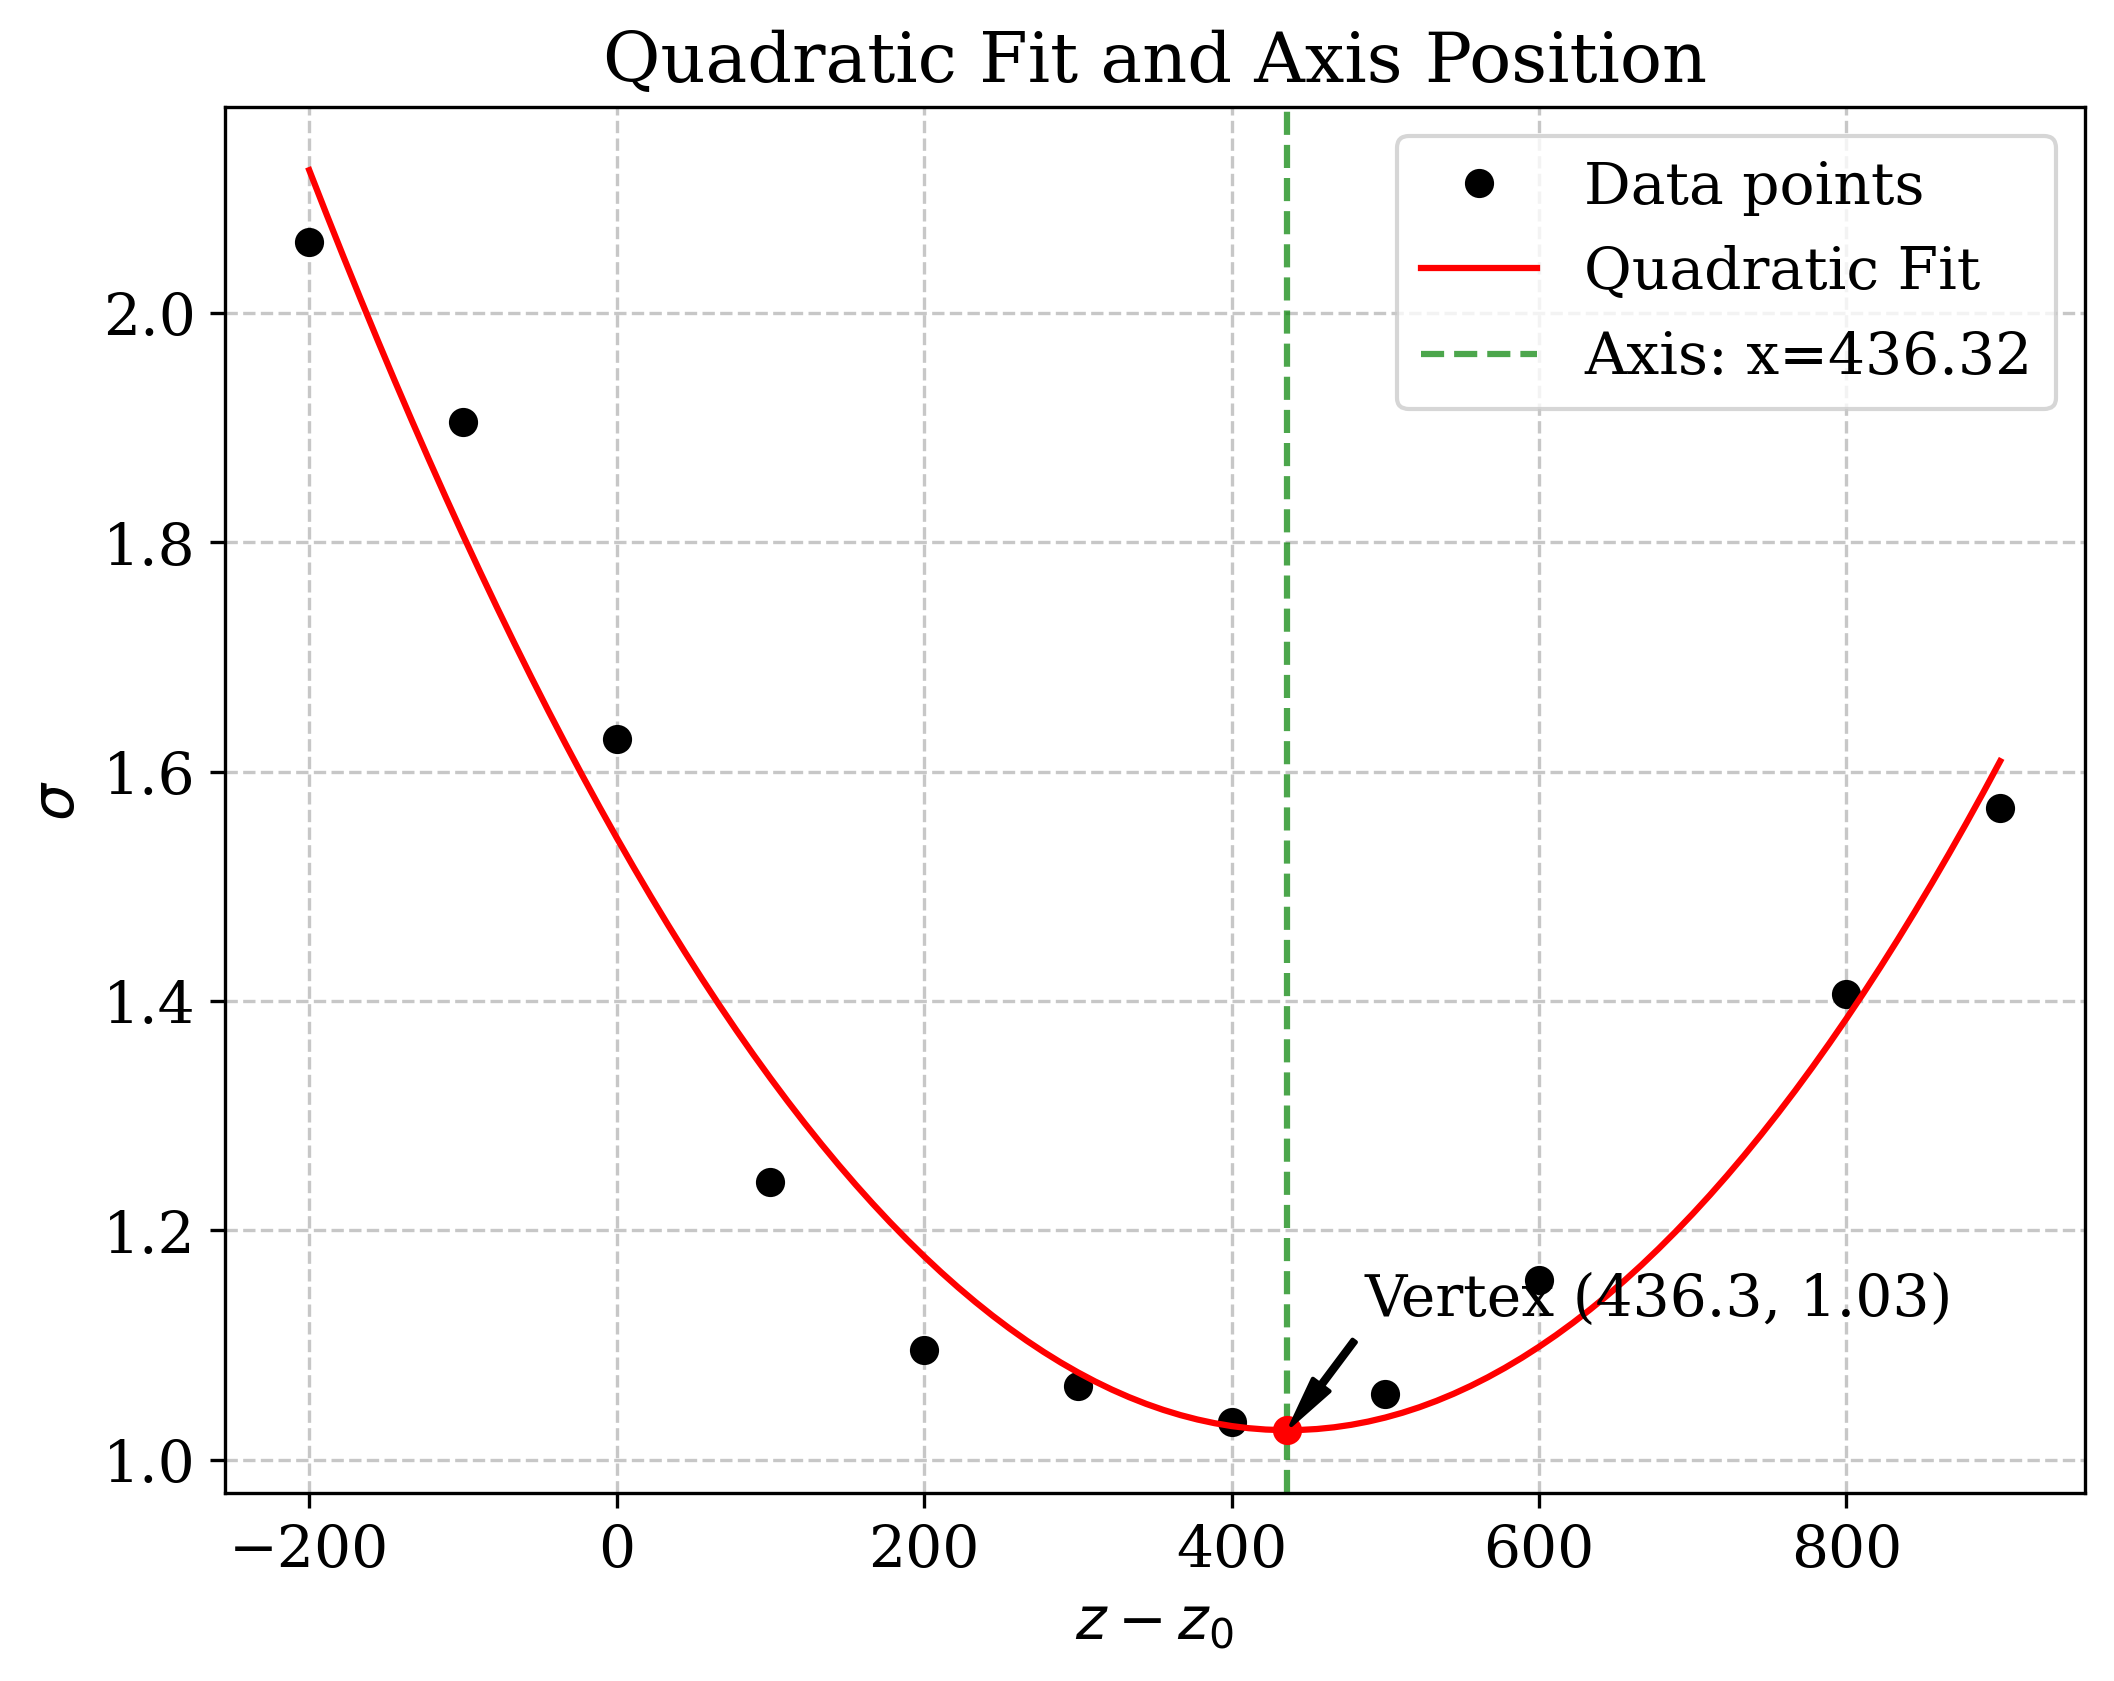

In [101]:
import numpy as np
import matplotlib.pyplot as plt

# 1. データの準備
# x_data = np.array([-200, -100, 0, 100, 200, 300, 400, 500, 600, 700, 800, 900])
# y_data = np.array([2.062, 1.905, 1.629, 1.242, 1.096, 1.064, 1.033, 1.057, 1.157, 1.435, 1.406, 1.568])

x_data = np.array([-200, -100, 0, 100, 200, 300, 400, 500, 600, 800, 900])
y_data = np.array([2.062, 1.905, 1.629, 1.242, 1.096, 1.064, 1.033, 1.057, 1.157, 1.406, 1.568])

# 2. フィッティングの実行
coeffs = np.polyfit(x_data, y_data, 2)
a, b, c = coeffs

# 3. 軸の計算 (x = -b / 2a)
axis_x = -b / (2 * a)
axis_y = np.polyval(coeffs, axis_x) # 頂点のy座標

print(f"軸の位置 (x): {axis_x:.2f}")
print(f"頂点の座標: ({axis_x:.2f}, {axis_y:.2f})")

# 4. プロット用のデータ作成
x_fit = np.linspace(min(x_data), max(x_data), 100)
y_fit = np.polyval(coeffs, x_fit)

# 5. 描画
plt.figure(figsize=(8, 6))
plt.plot(x_data, y_data, 'ko', label='Data points')
plt.plot(x_fit, y_fit, color='red', label='Quadratic Fit')

# 軸（垂直線）を表示
plt.axvline(x=axis_x, color='green', linestyle='--', alpha=0.7, label=f'Axis: x={axis_x:.2f}')

# 頂点にマークを付ける
plt.plot(axis_x, axis_y, 'ro')
plt.annotate(f'Vertex ({axis_x:.1f}, {axis_y:.2f})', 
             xy=(axis_x, axis_y), xytext=(axis_x+50, axis_y+0.1),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

# グラフの装飾
plt.title('Quadratic Fit and Axis Position')
plt.xlabel('$z-z_0$')
plt.ylabel('$\sigma$')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# plt.savefig('quadratic_fit_with_axis.png')
plt.show()

Fitting parameters and their uncertainties:
Amp: 32.863 ± 1.285
Mean: 7.028 ± 0.093
Sigma: 2.058 ± 0.093


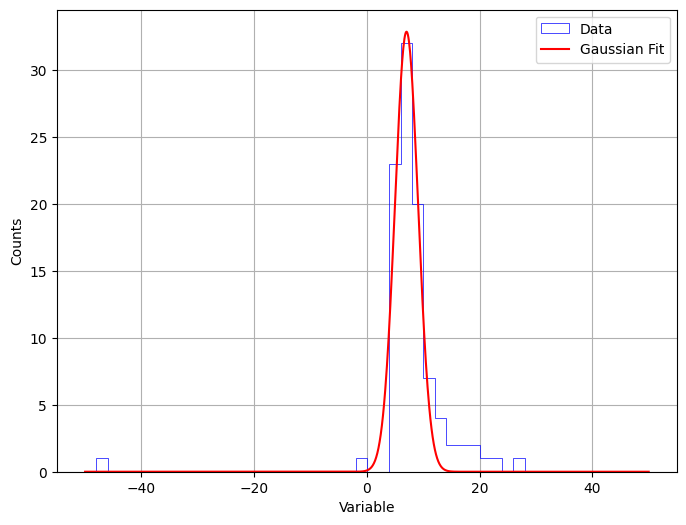

In [89]:
gated_310 = true_208Pb[(Tp <= 312) & (Tp >= 310)]

# シリーズのまま一括計算
GRX_310 = gated_310['GRX']
LASX_310 = gated_310['LASX']
LASA_310 = gated_310['LASA']

LASX_310m = LASX_310 - 200 * LASA_310

Tp_310 = (((GRX_310 * -0.0000454772 + 0.0027089081 + 1) * 832) ** 2 + 938.27 ** 2) ** 0.5 - 938.27
T_alpha_310 = 0.02746 * LASX_310m + 63.804

# Fitting
# Input
##############################################################
# Fitする変数
# variable = np.random.normal(loc=0, scale=10, size=1000)  # ダミーデータ
variable = 392 - Tp_310 - T_alpha_310
# Histogram range
hist_range_min = -50
hist_range_max = 50
# Bin width
bin_width = 2
# Fit range
fit_range_min = -20
fit_range_max = 100
# Initial parameters for the Gaussian
Amp = 250
mean = 10
sigma = 5
# Fit parameter boundaries
bound_min = [0, fit_range_min, 0]
bound_max = [np.inf, fit_range_max, np.inf]
##############################################################
# ガウシアン関数の定義
def gaussian(x, amp, mean, sigma):
    return amp * np.exp(-0.5 * ((x - mean) / sigma) ** 2)

# データ範囲の選択
bins = np.arange(hist_range_min, hist_range_max + bin_width, bin_width)
bin_counts, bin_edges = np.histogram(variable, bins=bins)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# フィット範囲を選択
mask = (bin_centers >= fit_range_min) & (bin_centers <= fit_range_max)
x_fit = bin_centers[mask]
y_fit = bin_counts[mask]

# 初期パラメータ
initial_guess = [Amp, mean, sigma]

# フィッティングを実行
popt, pcov = curve_fit(gaussian, x_fit, y_fit, p0=initial_guess, bounds=(bound_min, bound_max))

# フィット結果を取得
fit_y = gaussian(x_fit, *popt)

# 全てのフィッティングパラメータとその誤差を出力
print("Fitting parameters and their uncertainties:")
param_names = ["Amp", "Mean", "Sigma"]
for i, param in enumerate(popt):
    error = np.sqrt(pcov[i, i])
    print(f"{param_names[i]}: {param:.3f} ± {error:.3f}")

# フィット結果を描画
x_plot = np.linspace(hist_range_min, hist_range_max, 1000)
y_plot = gaussian(x_plot, *popt)

fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(variable, bins=bins, histtype='step', color='blue', linewidth=0.5, label='Data')
ax.plot(x_plot, y_plot, color='red', linewidth=1.5, label='Gaussian Fit')
ax.grid()
ax.set_xlabel('Variable')
ax.set_ylabel('Counts')
ax.legend()

Fitting result: f(x) = 2.5382e-06x^2 + -0.0023x + 1.5686


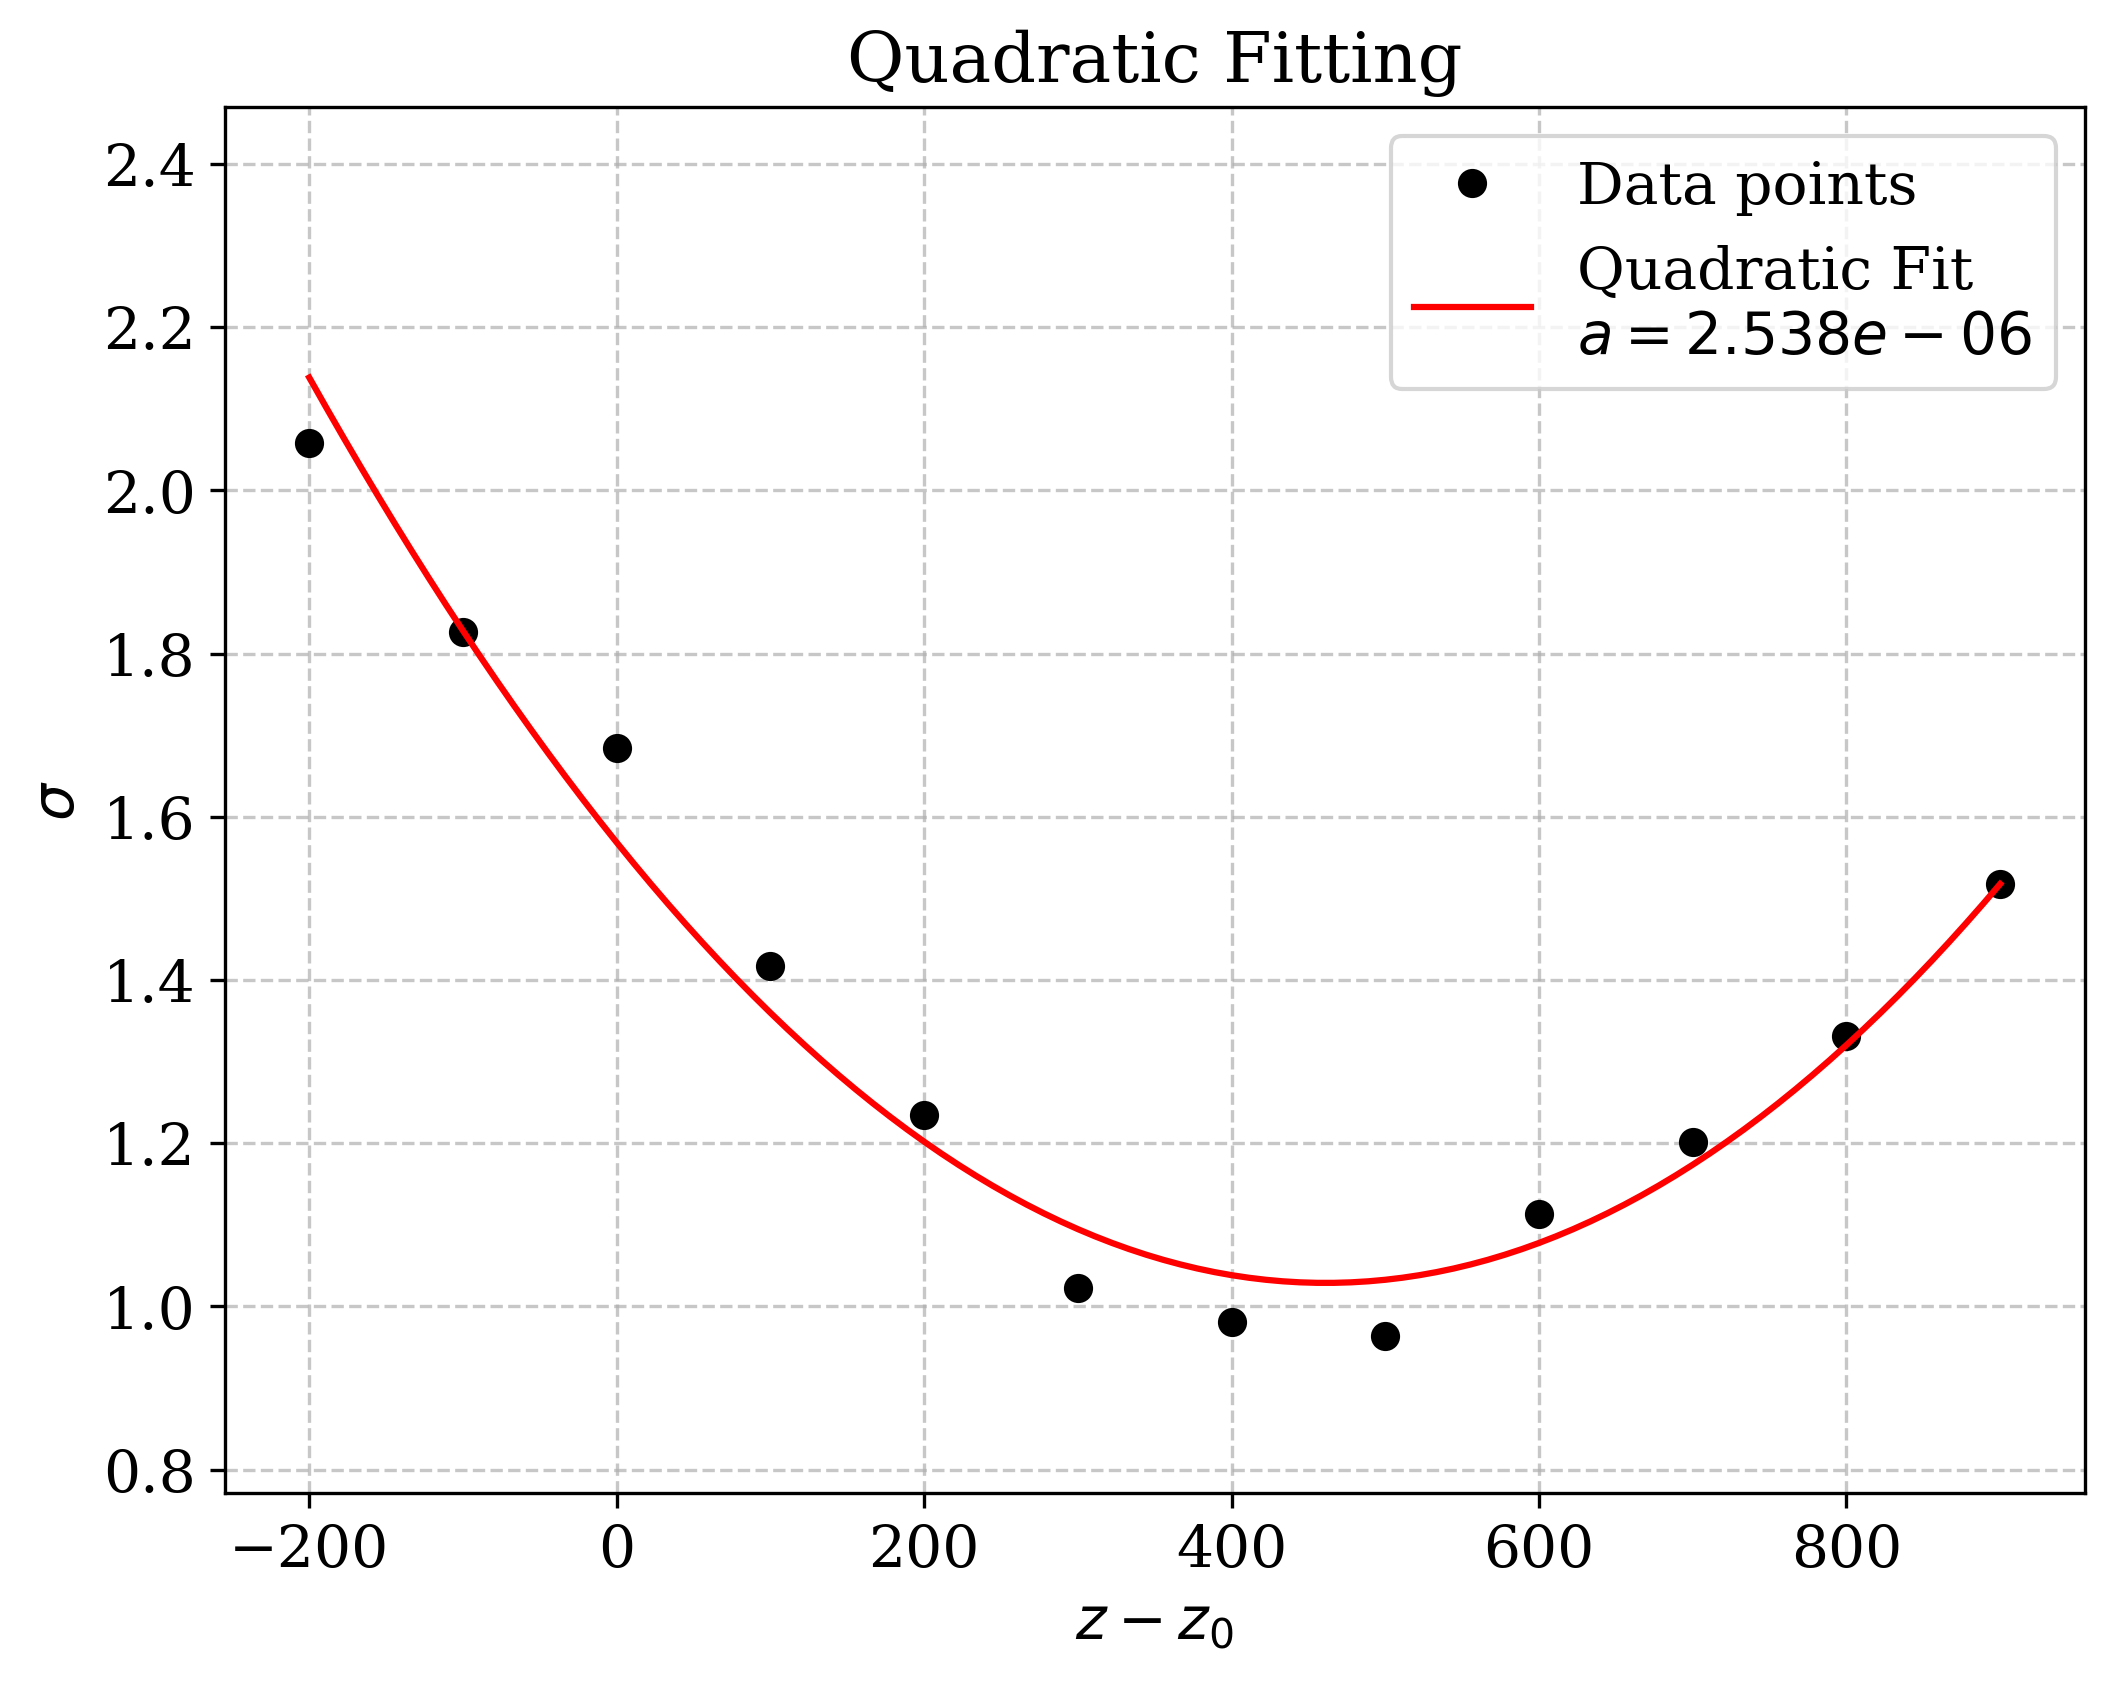

In [95]:
import numpy as np
import matplotlib.pyplot as plt

# 1. データの準備
# x_data = np.array([-400, -300, -200, -100, 0, 100, 200, 300, 400, 500, 600, 700, 800, 900])
# y_data = np.array([1.89, 1.78, 1.72, 1.68, 1.39, 1.19, 1, 0.85, 0.8, 0.53, 0.76, 0.93, 1.15, 1.255])

x_data = np.array([-200, -100, 0, 100, 200, 300, 400, 500, 600, 700, 800, 900])
y_data = np.array([2.058, 1.826, 1.684, 1.417, 1.235, 1.022, 0.981, 0.964, 1.113, 1.202, 1.332, 1.518])

# 2. フィッティングの実行 (np.polyfit を使用)
# 2次式なので 2 を指定。戻り値は [a, b, c] (ax^2 + bx + c)
coeffs = np.polyfit(x_data, y_data, 2)
a, b, c = coeffs

print(f"Fitting result: f(x) = {a:.4e}x^2 + {b:.4f}x + {c:.4f}")

# 3. プロット用のフィッティング曲線を作成
x_fit = np.linspace(min(x_data), max(x_data), 100)
# np.polyval を使うと係数から y の値を簡単に計算できます
y_fit = np.polyval(coeffs, x_fit)

# 4. 描画
plt.figure(figsize=(8, 6))

# データ点のプロット (誤差がないので scatter または plot)
plt.plot(x_data, y_data, 'ko', label='Data points')

# フィッティング曲線のプロット
plt.plot(x_fit, y_fit, color='red', label=f'Quadratic Fit\n$a={a:.3e}$')

# グラフの装飾
plt.title('Quadratic Fitting')
plt.xlabel('$z-z_0$')
plt.ylabel('$\sigma$')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# 軸の範囲を自動調整（異常値によるスケール崩れを防ぐ）
plt.ylim(min(y_data)*0.8, max(y_data)*1.2)

plt.savefig('fixed_quadratic_fit.png')
plt.show()

軸の位置 (x): 461.13
頂点の座標: (461.13, 1.03)


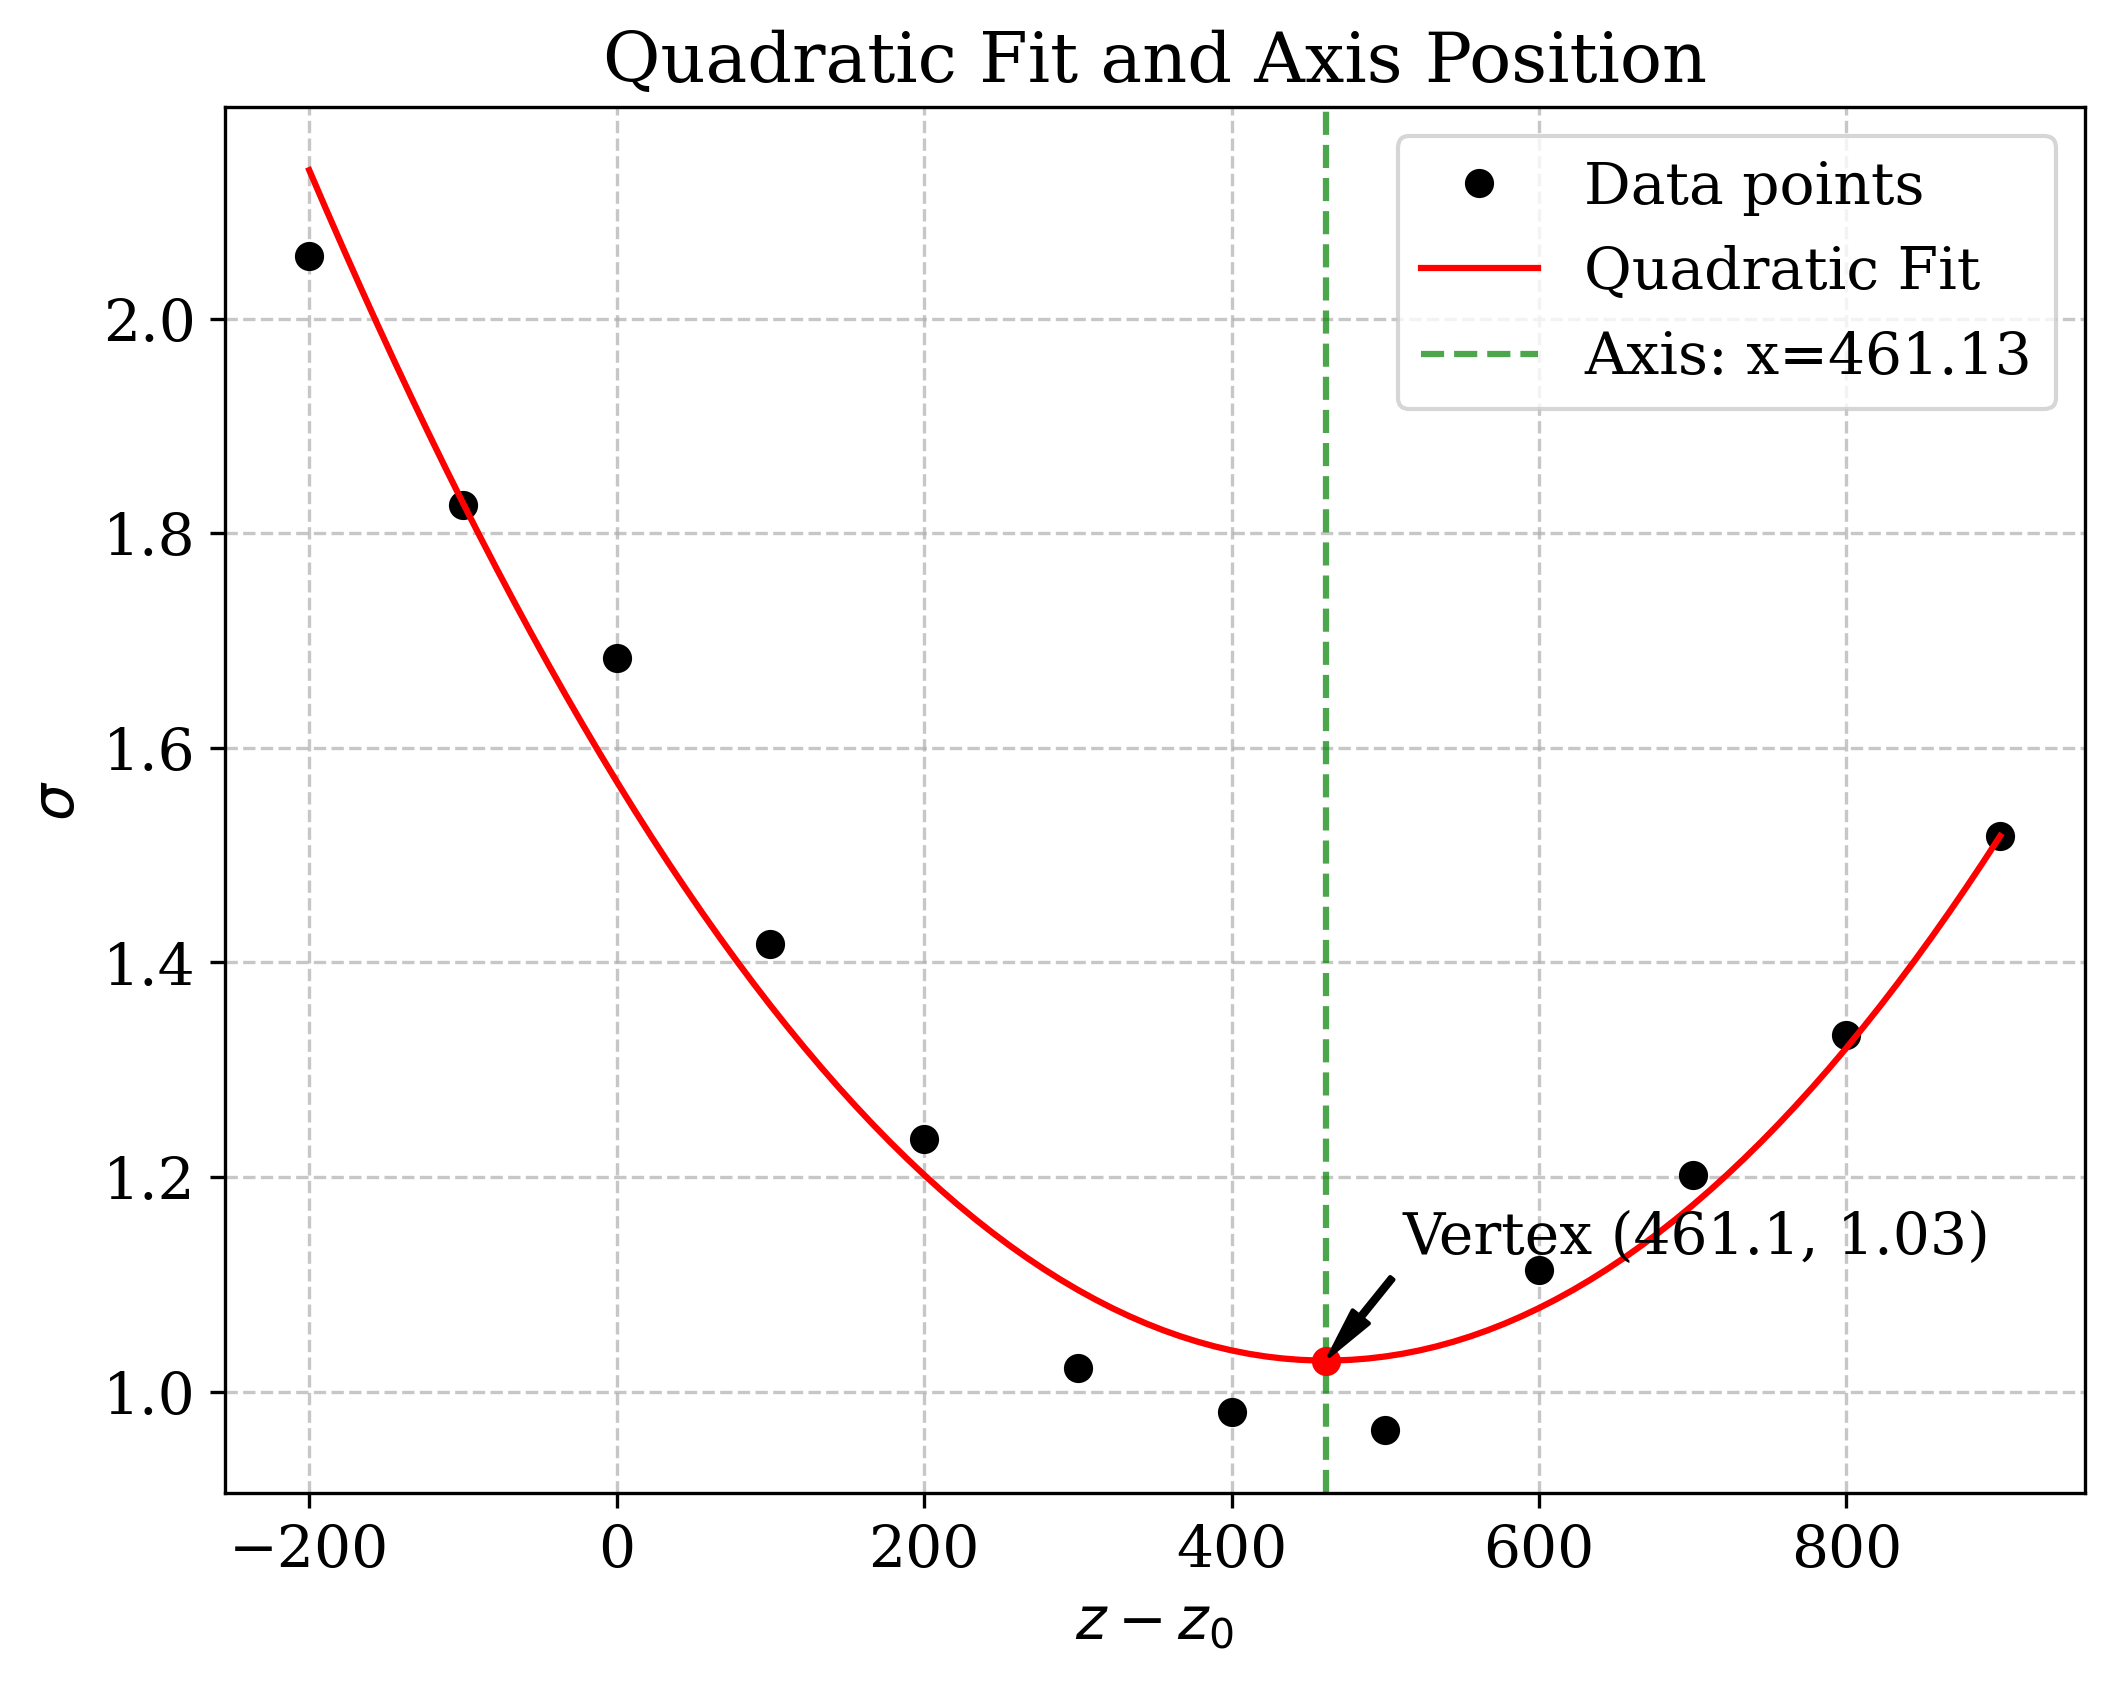

In [94]:
import numpy as np
import matplotlib.pyplot as plt

# 1. データの準備
# x_data = np.array([-400, -300, -200, -100, 0, 100, 200, 300, 400, 500, 600, 700, 800, 900])
# y_data = np.array([1.89, 1.78, 1.72, 1.68, 1.39, 1.19, 1, 0.85, 0.8, 0.53, 0.76, 0.93, 1.15, 1.255])

x_data = np.array([-200, -100, 0, 100, 200, 300, 400, 500, 600, 700, 800, 900])
y_data = np.array([2.058, 1.826, 1.684, 1.417, 1.235, 1.022, 0.981, 0.964, 1.113, 1.202, 1.332, 1.518])

# 2. フィッティングの実行
coeffs = np.polyfit(x_data, y_data, 2)
a, b, c = coeffs

# 3. 軸の計算 (x = -b / 2a)
axis_x = -b / (2 * a)
axis_y = np.polyval(coeffs, axis_x) # 頂点のy座標

print(f"軸の位置 (x): {axis_x:.2f}")
print(f"頂点の座標: ({axis_x:.2f}, {axis_y:.2f})")

# 4. プロット用のデータ作成
x_fit = np.linspace(min(x_data), max(x_data), 100)
y_fit = np.polyval(coeffs, x_fit)

# 5. 描画
plt.figure(figsize=(8, 6))
plt.plot(x_data, y_data, 'ko', label='Data points')
plt.plot(x_fit, y_fit, color='red', label='Quadratic Fit')

# 軸（垂直線）を表示
plt.axvline(x=axis_x, color='green', linestyle='--', alpha=0.7, label=f'Axis: x={axis_x:.2f}')

# 頂点にマークを付ける
plt.plot(axis_x, axis_y, 'ro')
plt.annotate(f'Vertex ({axis_x:.1f}, {axis_y:.2f})', 
             xy=(axis_x, axis_y), xytext=(axis_x+50, axis_y+0.1),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

# グラフの装飾
plt.title('Quadratic Fit and Axis Position')
plt.xlabel('$z-z_0$')
plt.ylabel('$\sigma$')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# plt.savefig('quadratic_fit_with_axis.png')
plt.show()

Weighted linear fit: y_axsis_variable = 0.8400000000 * x_axsis_variable + 186.8266666667


/var/folders/6q/n4qlty390djctk6jtn7xq4940000gn/T/ipykernel_1562/707507084.py:33: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(x_fit, y_fit_linear, 'r-', linewidth=2, label='Weighted Linear Fit', c='black')


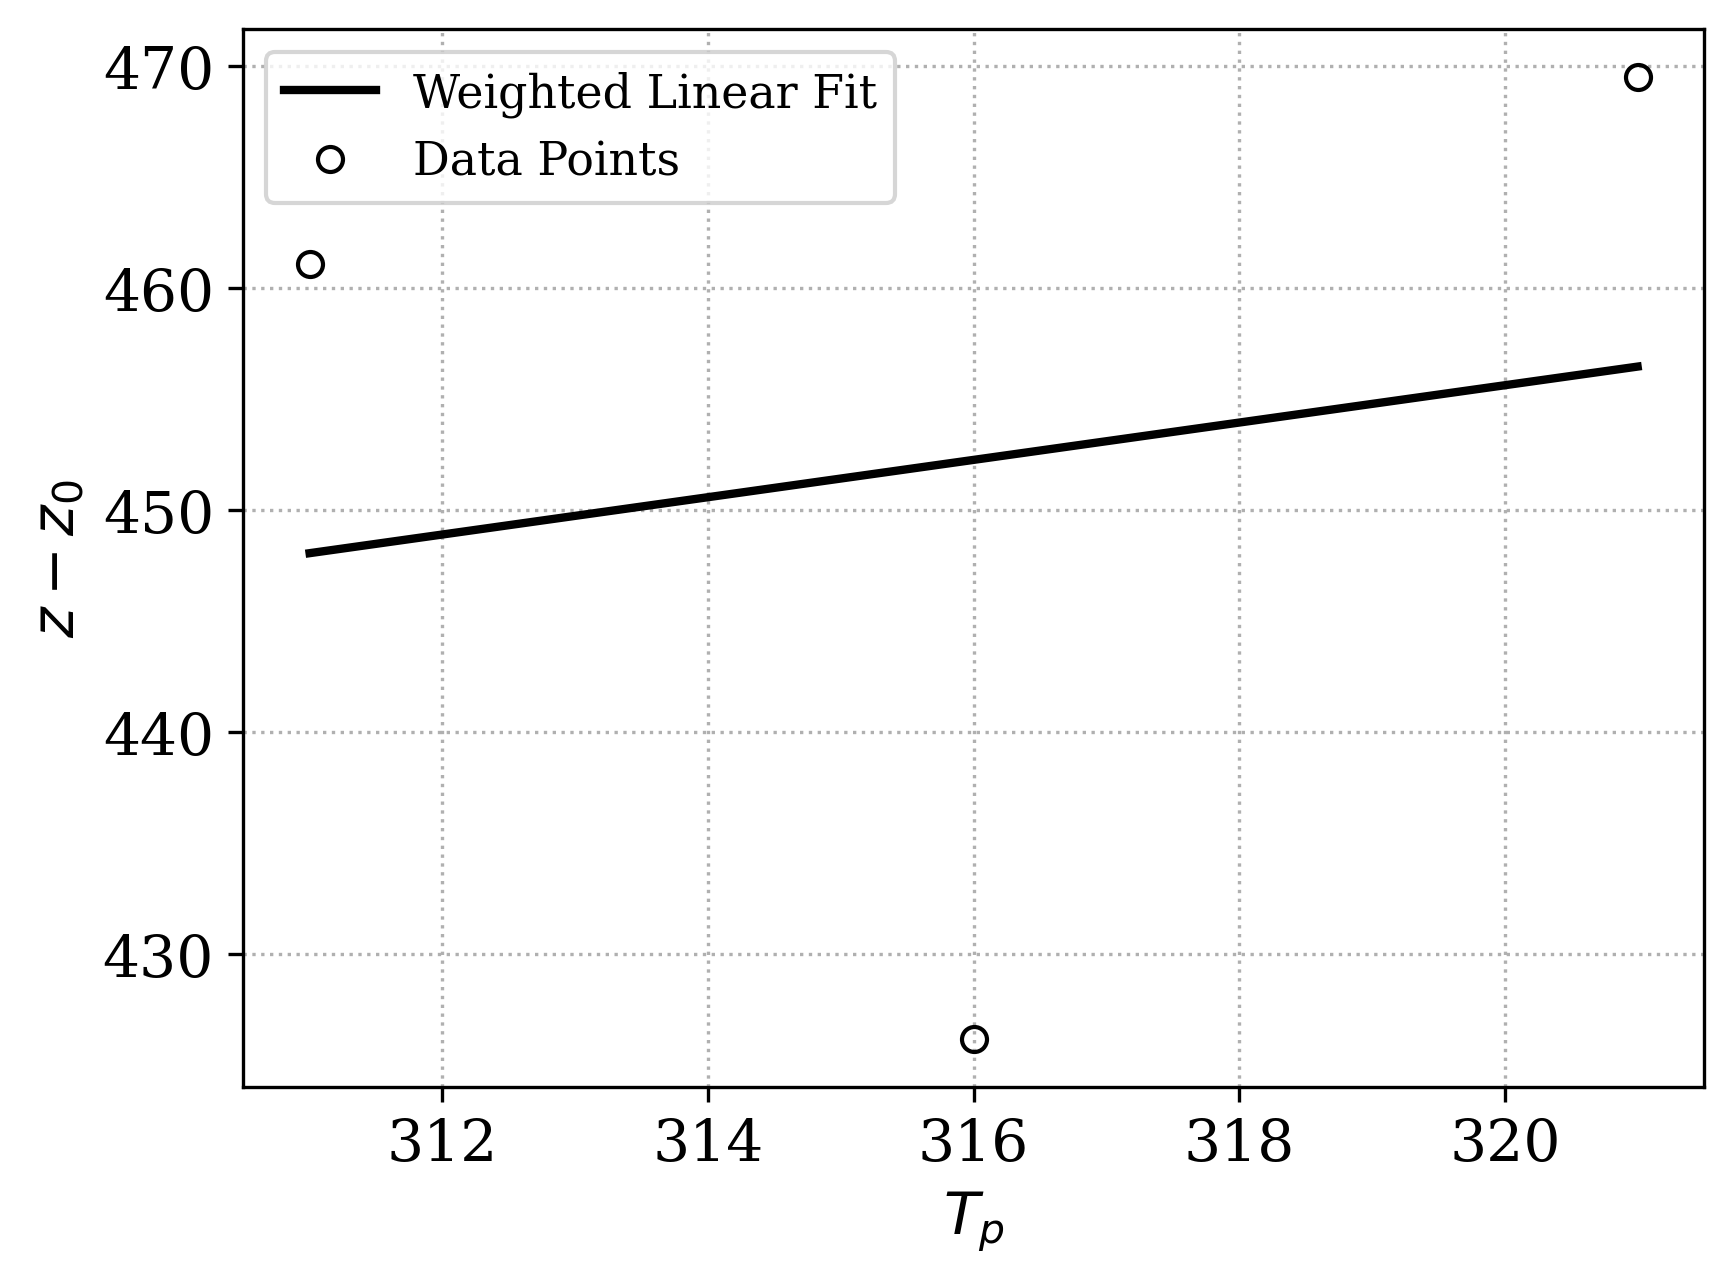

In [96]:
import numpy as np
import matplotlib.pyplot as plt

# inpiut###############################
x_axis_variable = np.array([311, 316, 321])
y_axis_variable = np.array([461.1, 426.2, 469.5])

hist_range_min=-0.011
hist_range_max=0.0009
#######################################


# ---------- 線形フィット ----------
coefficients_linear = np.polyfit(x_axis_variable, y_axis_variable, 1)
fit_func_linear = np.poly1d(coefficients_linear)
a_linear, b_linear = coefficients_linear

print(f"Weighted linear fit: y_axsis_variable = {a_linear:.10f} * x_axsis_variable + {b_linear:.10f}")

# ---------- 描画用 ----------
x_fit = np.linspace(min(x_axis_variable), max(x_axis_variable),1001)
y_fit_linear = fit_func_linear(x_fit)

plt.rcParams.update({
    'font.size': 14,
    'font.family': 'serif',
    'figure.dpi': 300
})

fig, ax = plt.subplots(figsize=(6, 4.5))

# フィット直線
ax.plot(x_fit, y_fit_linear, 'r-', linewidth=2, label='Weighted Linear Fit', c='black')

# エラーバー付きデータ点
ax.errorbar(x_axis_variable, y_axis_variable,
            fmt='o', markersize=6,
            capsize=4, capthick=1,
            markerfacecolor='none',       # 中を白抜き
            markeredgecolor='black',     # 枠線を黒に
            ecolor='gray',               # エラーバーの色
            label='Data Points')

# 軸ラベル
ax.set_xlabel('$T_p$')
ax.set_ylabel('$z-z_0$')

# グリッド・凡例
ax.grid(True, linestyle=':')
ax.legend(loc='best', fontsize=11)

plt.tight_layout()
plt.show()